# ============================================================
# PREDIKSI INDEKS KETAHANAN PANGAN (IKP)
# Metode: Machine Learning Regresi (CRISP-DM)
# Dataset: FSVA Indonesia 2021–2024
# ============================================================


In [46]:
# ============================================================
# TAHAP 1 — IMPORT LIBRARY & LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import shapiro, spearmanr
from scipy import stats

from sklearn.model_selection    import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.dummy              import DummyRegressor
from sklearn.linear_model       import LinearRegression
from sklearn.ensemble           import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics            import mean_absolute_error, mean_squared_error, \
                                       mean_absolute_percentage_error, r2_score

print("✅ Library berhasil diimport!")
print(f"Pandas  : {pd.__version__}")
print(f"Numpy   : {np.__version__}")

✅ Library berhasil diimport!
Pandas  : 2.2.2
Numpy   : 2.0.2


Seluruh library yang dibutuhkan berhasil diimpor tanpa error.

Library yang digunakan meliputi numpy dan pandas untuk manipulasi dan pengolahan data, matplotlib serta seaborn untuk visualisasi, scipy untuk pengujian statistik (Shapiro-Wilk dan Spearman), serta scikit-learn untuk proses pemodelan machine learning mencakup pembagian data, preprocessing, pemodelan regresi, evaluasi model, dan hyperparameter tuning.

Keberhasilan impor mengkonfirmasi bahwa lingkungan komputasi telah siap menjalankan seluruh tahapan analisis.

In [47]:
# ============================================================
# TAHAP 1 — LOAD DATASET
# ============================================================

df = pd.read_excel('/content/data_ketahanan_pangan.xlsx')

print(f"✅ Dataset berhasil dimuat!")
print(f"Ukuran dataset : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Periode data   : {df['Tahun'].min()} – {df['Tahun'].max()}")
print(f"Jumlah wilayah : {df['Wilayah'].nunique()} wilayah")
print(f"Jumlah provinsi: {df['Provinsi'].nunique()} provinsi")
display(df.head())

✅ Dataset berhasil dimuat!
Ukuran dataset : 2056 baris x 17 kolom
Periode data   : 2021 – 2024
Jumlah wilayah : 514 wilayah
Jumlah provinsi: 34 provinsi


,Tahun,Sumber_File,Wilayah,Provinsi,Kabupaten_Kota,Komposit,NCPR,Kemiskinan (%),Pengeluaran Pangan (%),Tanpa Listrik (%),Tanpa Air Bersih (%),Lama Sekolah Perempuan (tahun),Rasio Tenaga Kesehatan,Angka Harapan Hidup (tahun),Stunting (%),IKP,IKP Ranking
0,2021,tabel_data.csv,aceh - aceh selatan,Aceh,Aceh Selatan,5,0.84,12.10,37.42,0.00,34.05,8.50,2.22,64.81,40.2,73.84,267
1,2021,tabel_data.csv,aceh - aceh tenggara,Aceh,Aceh Tenggara,6,0.51,12.45,46.16,0.00,44.19,10.13,2.20,68.65,32.9,76.87,227
2,2021,tabel_data.csv,aceh - aceh timur,Aceh,Aceh Timur,6,0.72,13.39,31.97,0.45,38.66,8.99,1.68,69.07,29.7,77.19,217
3,2021,tabel_data.csv,aceh - aceh tengah,Aceh,Aceh Tengah,5,2.67,14.38,20.61,0.08,26.30,10.04,2.16,69.18,23.6,69.08,311
4,2021,tabel_data.csv,aceh - aceh barat,Aceh,Aceh Barat,6,0.67,17.86,31.65,0.00,23.36,10.27,1.46,68.34,33.4,78.27,204


Dataset berhasil dimuat dari file data_ketahanan_pangan.xlsx.

Dataset memiliki dimensi 2.056 baris × 17 kolom, mencakup 514 wilayah (kabupaten/kota) dari 34 provinsi di seluruh Indonesia dengan periode data 2021 hingga 2024.

Inspeksi awal melalui df.head() menunjukkan struktur data yang terdiri dari kolom identifikasi wilayah, indikator sosio-ekonomi dan kesehatan, serta variabel target IKP.

Dataset ini bersumber dari FSVA (Food Security and Vulnerability Atlas), sistem pemantauan ketahanan pangan resmi pemerintah Indonesia.

Tujuan pemodelan adalah membangun model regresi yang mampu memprediksi nilai IKP secara akurat berdasarkan indikator-indikator tersebut.

## Data Dictionary

Dataset bersumber dari FSVA (Food Security and Vulnerability Atlas) Indonesia 2021–2024.

| No | Kolom | Tipe | Deskripsi |
|---|---|---|---|
| 1 | Tahun | Numerik | Tahun pengamatan (2021–2024) |
| 2 | Wilayah | Kategorik | Nama kabupaten/kota |
| 3 | Provinsi | Kategorik | Nama provinsi |
| 4 | NCPR | Numerik | Normalized Caloric Poverty Ratio — rasio kecukupan kalori |
| 5 | Kemiskinan (%) | Numerik | Persentase penduduk miskin |
| 6 | Pengeluaran Pangan (%) | Numerik | Persentase pengeluaran untuk pangan |
| 7 | Tanpa Listrik (%) | Numerik | Persentase rumah tangga tanpa akses listrik |
| 8 | Tanpa Air Bersih (%) | Numerik | Persentase rumah tangga tanpa akses air bersih |
| 9 | Lama Sekolah Perempuan (tahun) | Numerik | Rata-rata lama sekolah perempuan |
| 10 | Rasio Tenaga Kesehatan | Numerik | Rasio tenaga kesehatan per penduduk |
| 11 | Angka Harapan Hidup (tahun) | Numerik | Angka harapan hidup saat lahir |
| 12 | Stunting (%) | Numerik | Prevalensi stunting pada balita |
| 13 | IKP Ranking | Numerik | Peringkat IKP — **dihapus** (data leakage) |
| 14 | Komposit | Numerik | Skor komposit IKP — **dihapus** (data leakage, r=0.95) |
| 15 | **IKP** ⭐ | **Numerik** | **TARGET — Indeks Ketahanan Pangan (nilai kontinu 0–100)** |

In [48]:
# ============================================================
# TAHAP 2 — EDA (EXPLORATORY DATA ANALYSIS)
# ============================================================

# ---- 2.1 Struktur Dataset ----
print("=== INFO DATASET ===")
df.info()
print("\n=== 5 BARIS PERTAMA ===")
display(df.head())
print("\n=== 5 BARIS TERAKHIR ===")
display(df.tail())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2056 entries, 0 to 2055
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Tahun                           2056 non-null   int64  
 1   Sumber_File                     2056 non-null   object 
 2   Wilayah                         2056 non-null   object 
 3   Provinsi                        2056 non-null   object 
 4   Kabupaten_Kota                  2056 non-null   object 
 5   Komposit                        2056 non-null   int64  
 6   NCPR                            2056 non-null   float64
 7   Kemiskinan (%)                  2056 non-null   float64
 8   Pengeluaran Pangan (%)          2056 non-null   float64
 9   Tanpa Listrik (%)               2056 non-null   float64
 10  Tanpa Air Bersih (%)            2056 non-null   float64
 11  Lama Sekolah Perempuan (tahun)  2056 non-null   float64
 12  Rasio Tenaga 

,Tahun,Sumber_File,Wilayah,Provinsi,Kabupaten_Kota,Komposit,NCPR,Kemiskinan (%),Pengeluaran Pangan (%),Tanpa Listrik (%),Tanpa Air Bersih (%),Lama Sekolah Perempuan (tahun),Rasio Tenaga Kesehatan,Angka Harapan Hidup (tahun),Stunting (%),IKP,IKP Ranking
0,2021,tabel_data.csv,aceh - aceh selatan,Aceh,Aceh Selatan,5,0.84,12.10,37.42,0.00,34.05,8.50,2.22,64.81,40.2,73.84,267
1,2021,tabel_data.csv,aceh - aceh tenggara,Aceh,Aceh Tenggara,6,0.51,12.45,46.16,0.00,44.19,10.13,2.20,68.65,32.9,76.87,227
2,2021,tabel_data.csv,aceh - aceh timur,Aceh,Aceh Timur,6,0.72,13.39,31.97,0.45,38.66,8.99,1.68,69.07,29.7,77.19,217
3,2021,tabel_data.csv,aceh - aceh tengah,Aceh,Aceh Tengah,5,2.67,14.38,20.61,0.08,26.30,10.04,2.16,69.18,23.6,69.08,311
4,2021,tabel_data.csv,aceh - aceh barat,Aceh,Aceh Barat,6,0.67,17.86,31.65,0.00,23.36,10.27,1.46,68.34,33.4,78.27,204



=== 5 BARIS TERAKHIR ===


,Tahun,Sumber_File,Wilayah,Provinsi,Kabupaten_Kota,Komposit,NCPR,Kemiskinan (%),Pengeluaran Pangan (%),Tanpa Listrik (%),Tanpa Air Bersih (%),Lama Sekolah Perempuan (tahun),Rasio Tenaga Kesehatan,Angka Harapan Hidup (tahun),Stunting (%),IKP,IKP Ranking
2051,2024,tabel_data (3).csv,papua barat - tambrauw,Papua Barat,Tambrauw,1,5.00,32.80,51.62,26.56,73.91,7.34,100.00,60.13,0.0,22.47,407
2052,2024,tabel_data (3).csv,papua barat - maybrat,Papua Barat,Maybrat,1,5.00,30.78,27.71,11.15,64.01,9.42,40.76,65.19,0.0,34.59,395
2053,2024,tabel_data (3).csv,papua barat - manokwari selatan,Papua Barat,Manokwari Selatan,4,1.22,28.88,29.60,2.50,38.83,8.39,28.12,67.58,0.0,65.31,329
2054,2024,tabel_data (3).csv,papua barat - pegunungan arfak,Papua Barat,Pegunungan Arfak,1,5.00,33.81,35.28,44.69,61.36,5.49,52.33,67.24,0.0,29.73,399
2055,2024,tabel_data (3).csv,papua barat - kota sorong,Papua Barat,Kota Sorong,6,0.00,14.99,6.27,0.20,3.55,10.82,0.67,70.70,0.0,71.89,69


Berdasarkan output df.info(), dataset terdiri dari 17 kolom dengan tipe data campuran — kolom numerik berupa int64 dan float64, serta kolom kategorik berupa object.

Seluruh 17 kolom terisi penuh dengan 2.056 entri tanpa adanya nilai kosong (Non-Null Count = 2.056 untuk semua kolom).


In [49]:
# ---- 2.2 Statistik Deskriptif ----
print("=== STATISTIK DESKRIPTIF ===")
display(df.describe().T.round(3))

=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
Tahun,2056.0,2022.500,1.118,2021.00,2021.750,2022.500,2023.250,2024.00
Komposit,2056.0,5.119,1.395,1.00,5.000,6.000,6.000,6.00
NCPR,2056.0,1.273,1.595,0.00,0.240,0.605,1.512,5.00
Kemiskinan (%),2056.0,11.852,7.342,2.02,6.780,10.015,14.412,42.03
Pengeluaran Pangan (%),2056.0,26.143,14.631,0.32,15.278,24.600,34.602,93.04
Tanpa Listrik (%),2056.0,2.663,8.255,0.00,0.000,0.200,1.240,96.76
Tanpa Air Bersih (%),2056.0,30.030,20.326,0.00,15.732,26.880,39.285,100.00
Lama Sekolah Perempuan (tahun),2056.0,8.705,1.574,1.28,7.858,8.610,9.622,13.26
Rasio Tenaga Kesehatan,2056.0,4.698,10.782,0.00,0.400,1.420,3.940,100.00
Angka Harapan Hidup (tahun),2056.0,69.834,3.433,55.27,67.660,70.110,72.200,77.93


Analisis statistik deskriptif dilakukan untuk memahami sebaran dan karakteristik masing-masing fitur numerik.

Variabel target IKP memiliki rata-rata 73,38, median 77,60, dan standar deviasi 14,58, mengindikasikan persebaran nilai yang cukup lebar antar kabupaten/kota.

Perbedaan antara mean dan median menunjukkan adanya kemiringan distribusi ke kiri, yang akan dikonfirmasi pada analisis distribusi selanjutnya.

In [50]:
# ---- 2.3 Missing Values ----
print("=== MISSING VALUES ===")
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing (%)', ascending=False)
display(missing)

mv = missing[missing['Missing Count'] > 0]
if len(mv) == 0:
    print("✅ Tidak ada missing values! Data sangat bersih.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(mv.index, mv['Missing (%)'], color='#E74C3C', edgecolor='black')
    ax.set_title('Persentase Missing Values per Kolom', fontweight='bold')
    ax.set_ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

=== MISSING VALUES ===


,Missing Count,Missing (%)
Tahun,0,0.0
Sumber_File,0,0.0
Wilayah,0,0.0
Provinsi,0,0.0
Kabupaten_Kota,0,0.0
Komposit,0,0.0
NCPR,0,0.0
Kemiskinan (%),0,0.0
Pengeluaran Pangan (%),0,0.0
Tanpa Listrik (%),0,0.0


✅ Tidak ada missing values! Data sangat bersih.


Tidak ditemukan satupun nilai hilang pada seluruh 17 kolom dan 2.056 baris data (Missing Count = 0, Missing (%) = 0,00 untuk semua kolom).

Kondisi ini menunjukkan kualitas pengumpulan data yang sangat baik sehingga tidak diperlukan proses imputasi apapun dalam tahap pembersihan data.

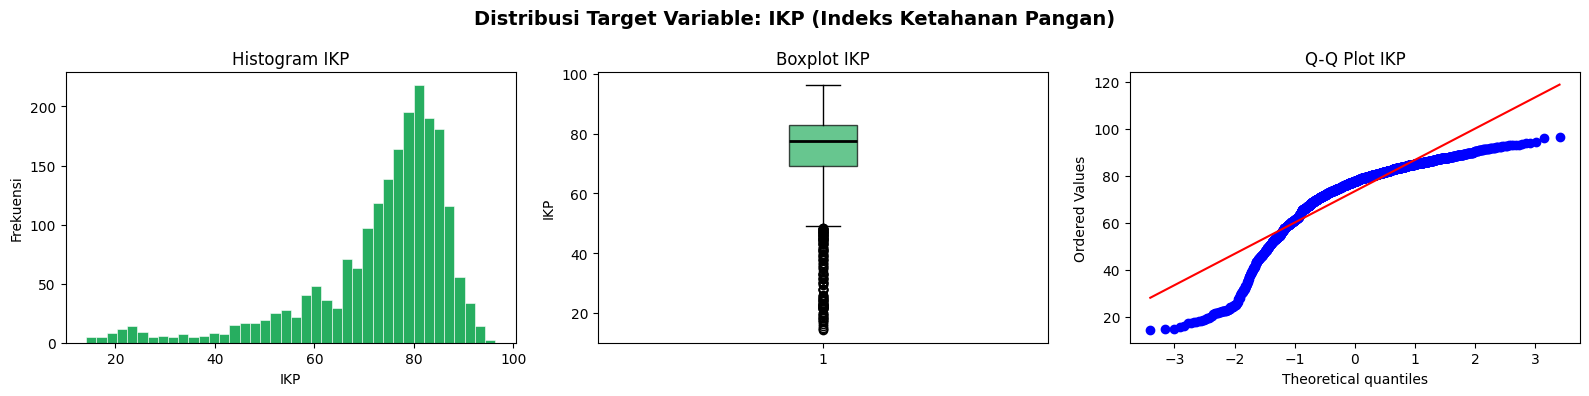


Statistik IKP:
  Min      : 14.14
  Max      : 96.37
  Mean     : 73.38
  Median   : 77.60
  Std Dev  : 14.58
  Skewness : -1.7427


In [51]:
# ---- 2.4 Distribusi Target (IKP) ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribusi Target Variable: IKP (Indeks Ketahanan Pangan)',
             fontsize=14, fontweight='bold')

axes[0].hist(df['IKP'], bins=40, color='#27AE60', edgecolor='white', linewidth=0.4)
axes[0].set_title('Histogram IKP')
axes[0].set_xlabel('IKP')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df['IKP'], patch_artist=True,
                boxprops=dict(facecolor='#27AE60', alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Boxplot IKP')
axes[1].set_ylabel('IKP')

stats.probplot(df['IKP'], plot=axes[2])
axes[2].set_title('Q-Q Plot IKP')

plt.tight_layout()
plt.show()

print(f"\nStatistik IKP:")
print(f"  Min      : {df['IKP'].min():.2f}")
print(f"  Max      : {df['IKP'].max():.2f}")
print(f"  Mean     : {df['IKP'].mean():.2f}")
print(f"  Median   : {df['IKP'].median():.2f}")
print(f"  Std Dev  : {df['IKP'].std():.2f}")
print(f"  Skewness : {df['IKP'].skew():.4f}")

Berdasarkan visualisasi histogram, boxplot, dan Q-Q Plot, distribusi IKP menunjukkan karakteristik sebagai berikut:

nilai minimum 14,14, nilai maksimum 96,37, rata-rata 73,38, median 77,60, standar deviasi 14,58, dan skewness −1,74.

Nilai skewness negatif mengindikasikan distribusi condong ke kiri, artinya sebagian besar kabupaten/kota memiliki nilai IKP yang relatif tinggi sementara terdapat ekor panjang ke arah nilai rendah.

Q-Q Plot menunjukkan deviasi dari normalitas terutama pada nilai-nilai ekstrem di ekor distribusi, yang merupakan kondisi wajar untuk data sosial-ekonomi yang dipengaruhi ketimpangan antar wilayah.

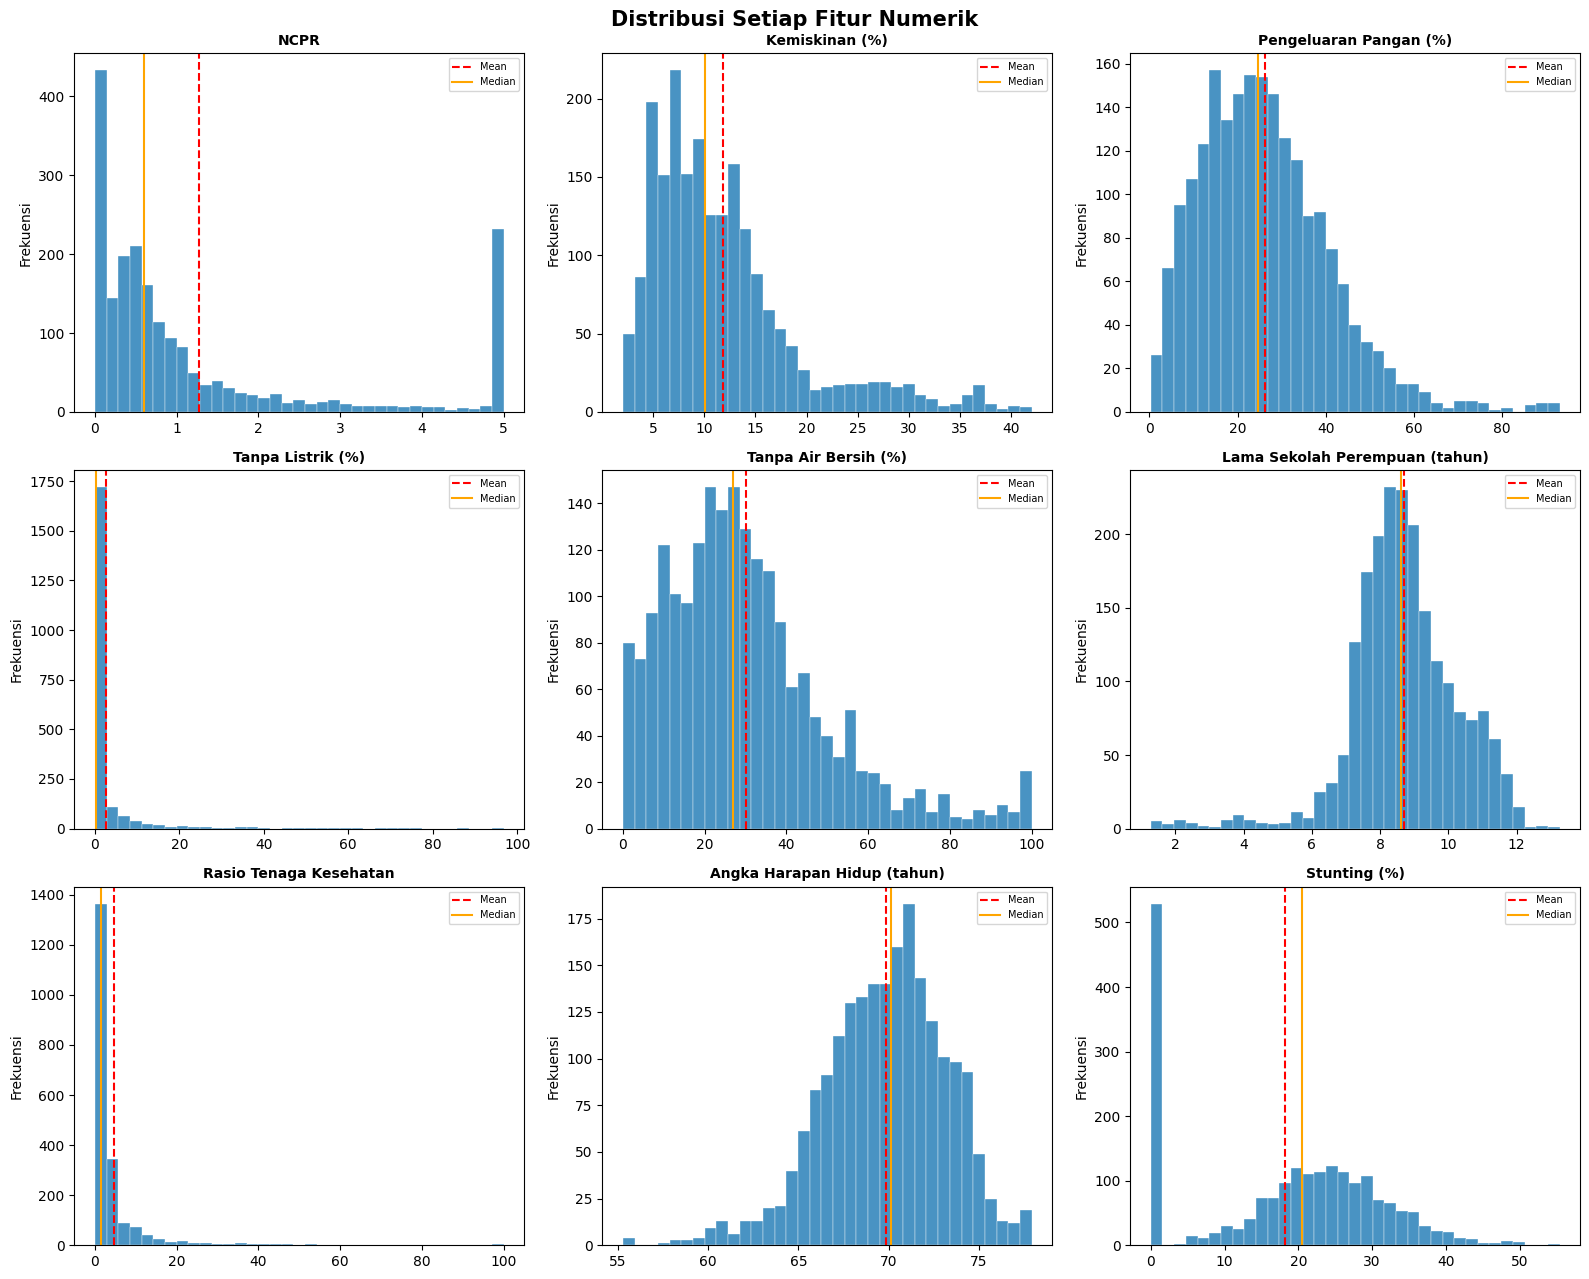

In [52]:
# ---- 2.5 Distribusi Semua Fitur Numerik ----
fitur_num = ['NCPR', 'Kemiskinan (%)', 'Pengeluaran Pangan (%)',
             'Tanpa Listrik (%)', 'Tanpa Air Bersih (%)',
             'Lama Sekolah Perempuan (tahun)', 'Rasio Tenaga Kesehatan',
             'Angka Harapan Hidup (tahun)', 'Stunting (%)']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Distribusi Setiap Fitur Numerik', fontsize=15, fontweight='bold')
for i, feat in enumerate(fitur_num):
    ax = axes[i//3, i%3]
    ax.hist(df[feat], bins=35, color='#2980B9', edgecolor='white', alpha=0.85, linewidth=0.3)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Frekuensi')
    ax.axvline(df[feat].mean(),   color='red',    linestyle='--', lw=1.5, label='Mean')
    ax.axvline(df[feat].median(), color='orange', linestyle='-',  lw=1.5, label='Median')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

Visualisasi histogram dari 9 fitur numerik (NCPR, Kemiskinan (%), Pengeluaran Pangan (%), Tanpa Listrik (%), Tanpa Air Bersih (%), Lama Sekolah Perempuan (tahun), Rasio Tenaga Kesehatan, Angka Harapan Hidup (tahun), Stunting (%)) dilengkapi dengan garis mean (merah putus-putus) dan median (oranye).

Sebagian besar fitur menunjukkan distribusi yang tidak simetris dan condong ke kanan (right-skewed), khususnya Tanpa Listrik (%), NCPR, dan Kemiskinan (%), yang mencerminkan ketimpangan akses layanan dasar dan kondisi sosio-ekonomi antar wilayah di Indonesia.

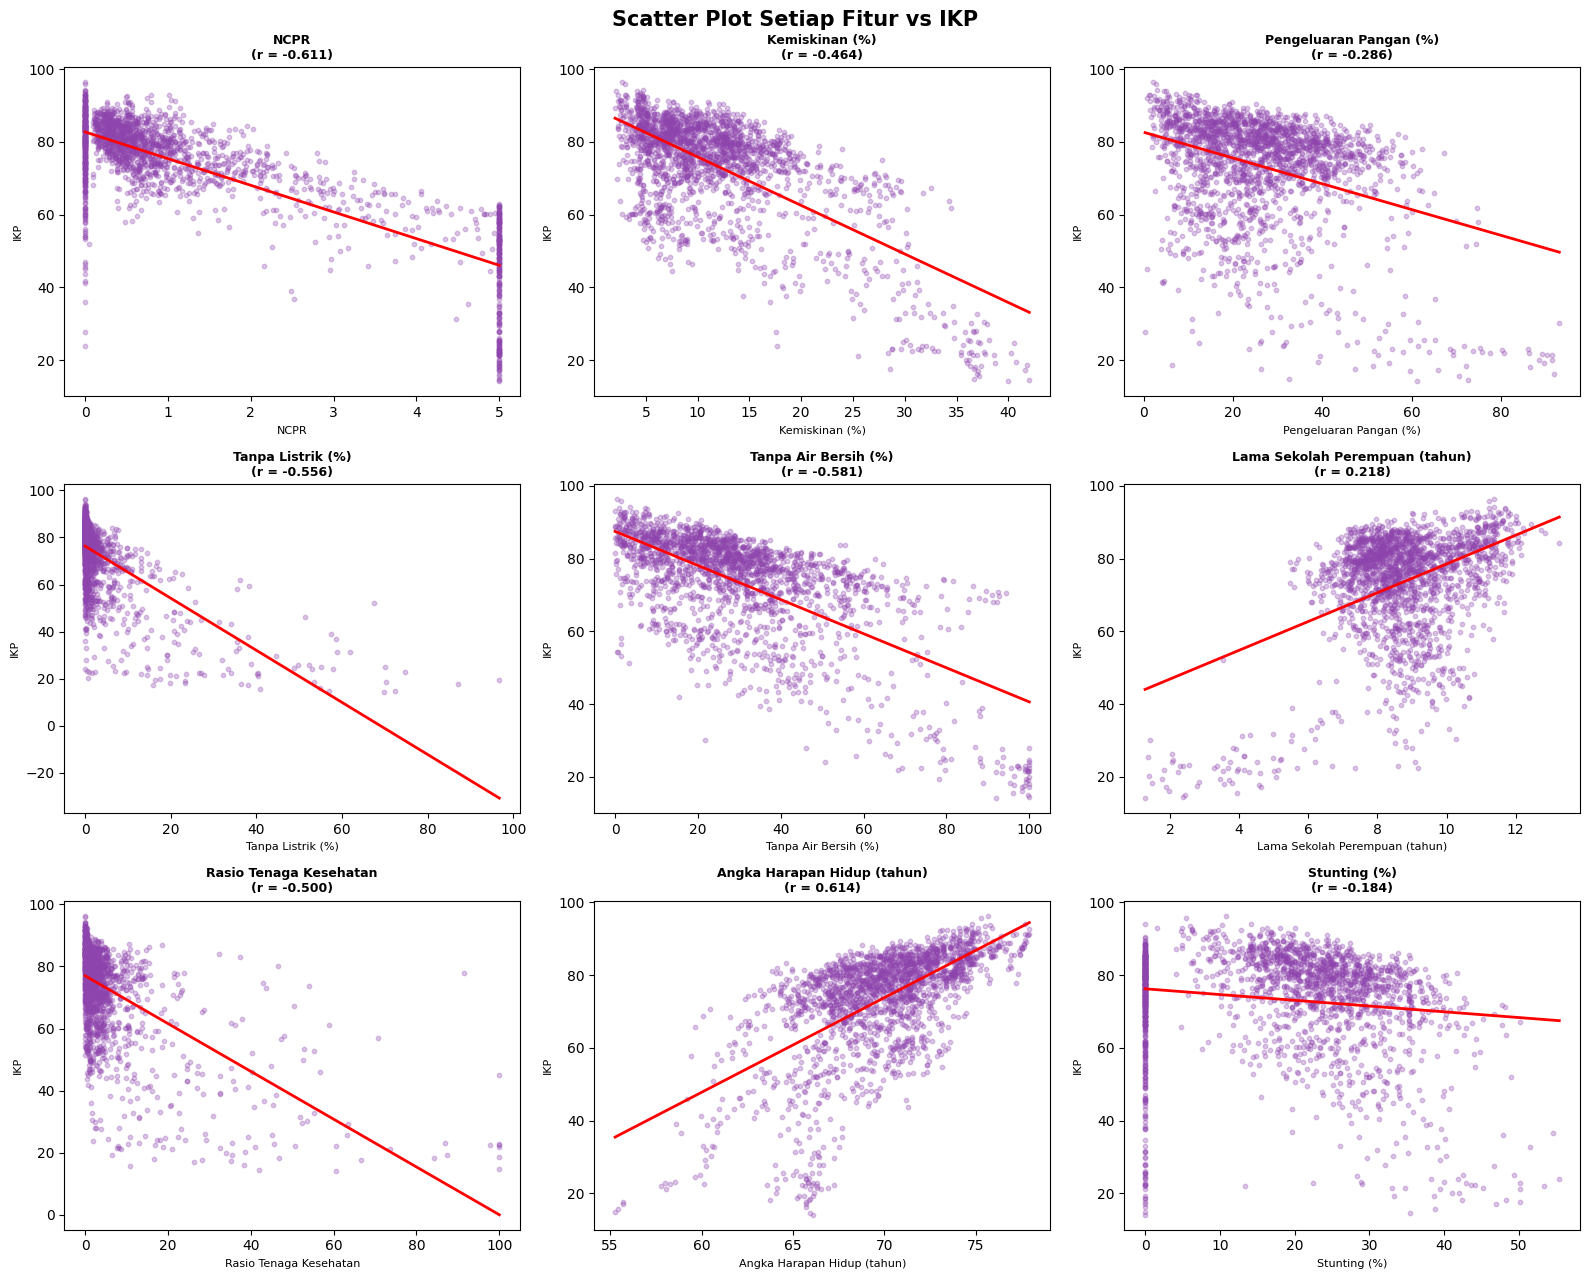

In [53]:
# ---- 2.6 Scatter Plot Fitur vs IKP ----
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Scatter Plot Setiap Fitur vs IKP', fontsize=15, fontweight='bold')
for i, feat in enumerate(fitur_num):
    ax = axes[i//3, i%3]
    ax.scatter(df[feat], df['IKP'], alpha=0.3, s=10, color='#8E44AD')
    z = np.polyfit(df[feat].dropna(), df.loc[df[feat].notna(), 'IKP'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', lw=2)
    r, _ = spearmanr(df[feat], df['IKP'])
    ax.set_title(f'{feat}\n(r = {r:.3f})', fontsize=9, fontweight='bold')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('IKP', fontsize=8)
plt.tight_layout()
plt.show()

Analisis scatter plot dari setiap fitur terhadap IKP dilengkapi dengan garis tren regresi dan nilai korelasi Spearman.

Fitur NCPR menunjukkan korelasi Spearman r = −0,611 (hubungan negatif kuat): semakin tinggi nilai NCPR, semakin rendah IKP.

Angka Harapan Hidup (tahun) menunjukkan korelasi positif, sedangkan Tanpa Air Bersih (%), Kemiskinan (%), dan Tanpa Listrik (%) menunjukkan hubungan negatif yang signifikan. Fitur Stunting (%) dan Pengeluaran Pangan (%) menunjukkan korelasi yang lebih lemah dibanding fitur lainnya.

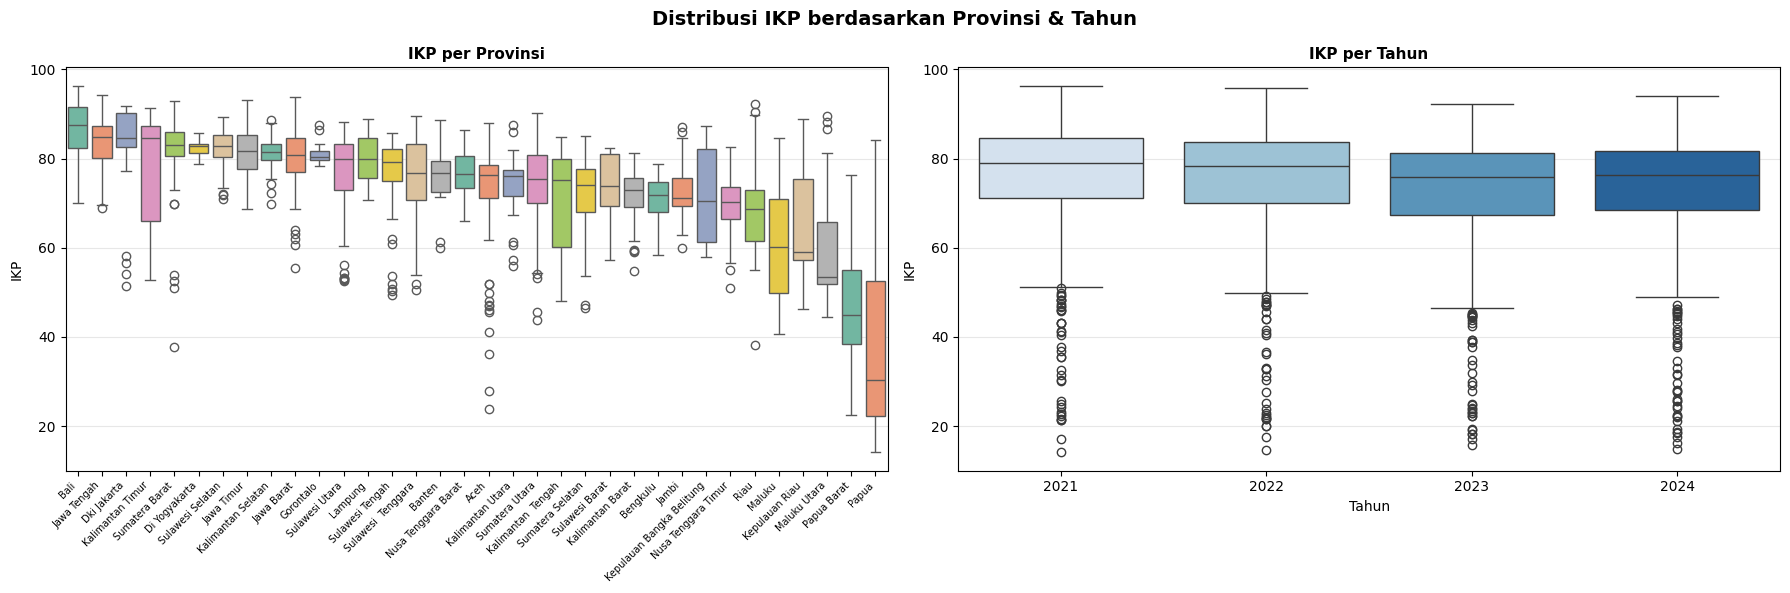

In [54]:
# ---- 2.7 Distribusi IKP per Provinsi & Tahun ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribusi IKP berdasarkan Provinsi & Tahun',
             fontsize=14, fontweight='bold')

provinsi_order = df.groupby('Provinsi')['IKP'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Provinsi', y='IKP',
            order=provinsi_order, palette='Set2', ax=axes[0])
axes[0].set_title('IKP per Provinsi', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=45, ha='right', fontsize=7)
axes[0].set_xlabel('')
axes[0].set_ylabel('IKP')
axes[0].grid(axis='y', alpha=0.3)

sns.boxplot(data=df, x='Tahun', y='IKP', palette='Blues', ax=axes[1])
axes[1].set_title('IKP per Tahun', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('IKP')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Boxplot IKP per provinsi (diurutkan berdasarkan median tertinggi ke terendah) menunjukkan variasi yang signifikan antar provinsi.

Beberapa provinsi di Pulau Jawa dan Bali cenderung memiliki median IKP lebih tinggi, sementara sejumlah provinsi di kawasan timur Indonesia menunjukkan median IKP yang lebih rendah.

Boxplot IKP per tahun (2021–2024) menunjukkan distribusi yang relatif stabil dari tahun ke tahun, mengindikasikan tidak adanya perubahan struktural yang dramatis selama periode pengamatan.

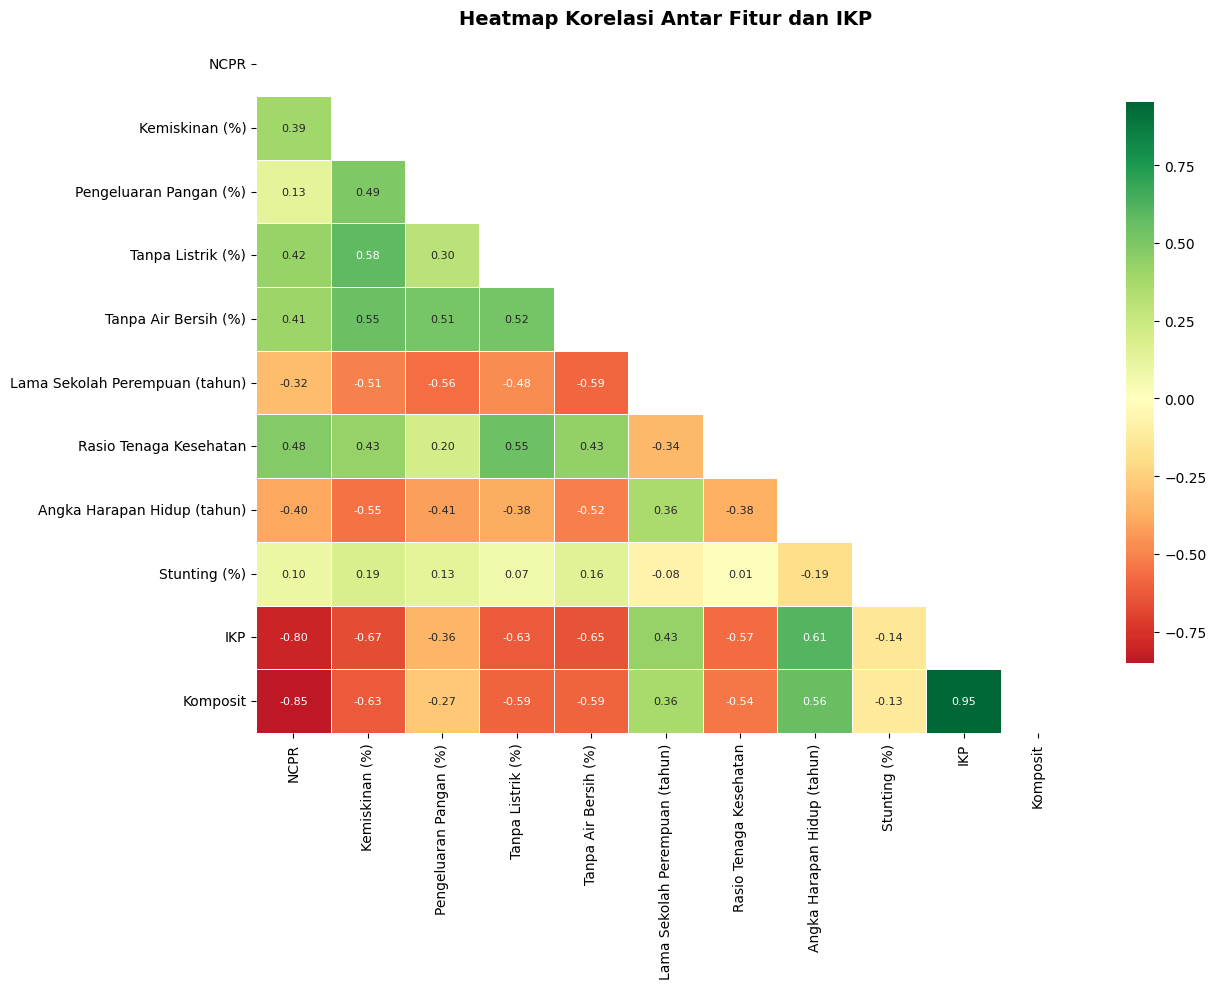


Korelasi Fitur dengan IKP (diurutkan):
Komposit                          0.9516
Angka Harapan Hidup (tahun)       0.6123
Lama Sekolah Perempuan (tahun)    0.4270
Stunting (%)                     -0.1397
Pengeluaran Pangan (%)           -0.3555
Rasio Tenaga Kesehatan           -0.5690
Tanpa Listrik (%)                -0.6265
Tanpa Air Bersih (%)             -0.6533
Kemiskinan (%)                   -0.6714
NCPR                             -0.8021

CATATAN PENTING:
  Variabel 'Komposit' menunjukkan korelasi sangat tinggi
  dengan IKP (r = 0.9516).
  Hal ini mengindikasikan DATA LEAKAGE karena 'Komposit'
  merupakan skor gabungan dari komponen IKP itu sendiri.
  → Variabel 'Komposit' akan DIHAPUS.


In [55]:
# ---- 2.8 Heatmap Korelasi ----
# Komposit disertakan di EDA untuk menunjukkan korelasi tinggi dengan IKP
# sebagai justifikasi penghapusannya pada Tahap 4 (data leakage)
df_corr = df[fitur_num + ['IKP', 'Komposit']].copy()

fig, ax = plt.subplots(figsize=(13, 10))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Antar Fitur dan IKP',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKorelasi Fitur dengan IKP (diurutkan):")
corr_ikp = corr['IKP'].drop('IKP').sort_values(ascending=False)
print(corr_ikp.round(4).to_string())

print("\n" + "="*60)
print("CATATAN PENTING:")
print("  Variabel 'Komposit' menunjukkan korelasi sangat tinggi")
print(f"  dengan IKP (r = {corr.loc['Komposit','IKP']:.4f}).")
print("  Hal ini mengindikasikan DATA LEAKAGE karena 'Komposit'")
print("  merupakan skor gabungan dari komponen IKP itu sendiri.")
print("  → Variabel 'Komposit' akan DIHAPUS.")
print("="*60)

Heatmap korelasi Pearson yang mencakup seluruh fitur numerik, IKP, dan variabel Komposit menunjukkan temuan penting.

Variabel Komposit memiliki korelasi r = 0,9516 terhadap IKP — jauh melampaui fitur-fitur lainnya.

Fitur dengan korelasi terkuat secara alami terhadap IKP adalah NCPR (r = −0,8021), Kemiskinan (%) (r = −0,6714), Tanpa Air Bersih (%) (r = −0,6533), Tanpa Listrik (%) (r = −0,6265), dan Angka Harapan Hidup (tahun) (r = +0,6123).

Korelasi sangat tinggi Komposit terhadap IKP (r = 0,9516) mengkonfirmasi bahwa variabel ini merupakan skor gabungan yang diturunkan dari komponen IKP itu sendiri, sehingga harus dihapus pada tahap pembersihan data untuk menghindari data leakage.

In [56]:
# ============================================================
# TAHAP 3 — VALIDASI DATA
# ============================================================

# ---- 3.1 Uji Normalitas (Shapiro-Wilk) ----
print("=== UJI NORMALITAS (SHAPIRO-WILK, n=300 sampel) ===")
print(f"{'Variabel':<35} {'Statistik':>10} {'p-value':>12} {'Normal?':>10}")
print('-' * 72)
for col in fitur_num + ['IKP']:
    sample = df[col].dropna().sample(n=min(300, len(df[col].dropna())), random_state=42)
    stat, p = shapiro(sample)
    normal = 'Ya ✓' if p > 0.05 else 'Tidak ✗'
    print(f"{col:<35} {stat:>10.4f} {p:>12.6f} {normal:>10}")

=== UJI NORMALITAS (SHAPIRO-WILK, n=300 sampel) ===
Variabel                             Statistik      p-value    Normal?
------------------------------------------------------------------------
NCPR                                    0.7369     0.000000    Tidak ✗
Kemiskinan (%)                          0.8403     0.000000    Tidak ✗
Pengeluaran Pangan (%)                  0.9186     0.000000    Tidak ✗
Tanpa Listrik (%)                       0.3537     0.000000    Tidak ✗
Tanpa Air Bersih (%)                    0.8942     0.000000    Tidak ✗
Lama Sekolah Perempuan (tahun)          0.9470     0.000000    Tidak ✗
Rasio Tenaga Kesehatan                  0.4260     0.000000    Tidak ✗
Angka Harapan Hidup (tahun)             0.9759     0.000061    Tidak ✗
Stunting (%)                            0.9133     0.000000    Tidak ✗
IKP                                     0.7889     0.000000    Tidak ✗


Uji Shapiro-Wilk dilakukan pada sampel 300 data untuk setiap variabel. Seluruh 10 variabel (9 fitur + IKP) menghasilkan p-value = 0,000000 dengan nilai statistik yang jauh di bawah 1,0 — mengkonfirmasi bahwa tidak satupun variabel memenuhi asumsi normalitas (p < 0,05 untuk semua).

Sebagai contoh, NCPR menghasilkan statistik = 0,7369, Kemiskinan (%) = 0,8403, dan Tanpa Listrik (%) = 0,3537 — nilai-nilai statistik yang sangat rendah ini menandakan distribusi yang sangat jauh dari normal.

Kondisi ini merupakan hal yang umum pada dataset sosio-ekonomi berskala besar yang mencerminkan heterogenitas antar wilayah, dan menjadi dasar penggunaan uji korelasi non-parametrik Spearman pada langkah berikutnya.

In [57]:
# ---- 3.2 Uji Korelasi Spearman (Fitur vs IKP) ----
print("=== UJI KORELASI SPEARMAN (Fitur vs IKP) ===")
print(f"{'Fitur':<35} {'r Spearman':>12} {'p-value':>12} {'Signifikan?':>14}")
print('-' * 76)
for feat in fitur_num:
    r, p = spearmanr(df[feat], df['IKP'])
    sig = 'Ya ✓' if p < 0.05 else 'Tidak ✗'
    print(f"{feat:<35} {r:>12.4f} {p:>12.6f} {sig:>14}")

=== UJI KORELASI SPEARMAN (Fitur vs IKP) ===
Fitur                                 r Spearman      p-value    Signifikan?
----------------------------------------------------------------------------
NCPR                                     -0.6113     0.000000           Ya ✓
Kemiskinan (%)                           -0.4639     0.000000           Ya ✓
Pengeluaran Pangan (%)                   -0.2861     0.000000           Ya ✓
Tanpa Listrik (%)                        -0.5560     0.000000           Ya ✓
Tanpa Air Bersih (%)                     -0.5806     0.000000           Ya ✓
Lama Sekolah Perempuan (tahun)            0.2182     0.000000           Ya ✓
Rasio Tenaga Kesehatan                   -0.4997     0.000000           Ya ✓
Angka Harapan Hidup (tahun)               0.6143     0.000000           Ya ✓
Stunting (%)                             -0.1842     0.000000           Ya ✓


Seluruh 9 fitur numerik menunjukkan korelasi Spearman yang signifikan secara statistik dengan p-value = 0,000000 (jauh di bawah α = 0,05) untuk semua fitur. Korelasi tertinggi ditunjukkan oleh NCPR (r = −0,6113), Tanpa Air Bersih (%) (r = −0,5806), dan Tanpa Listrik (%) (r = −0,5560).

Semua 9 fitur memperoleh status "Ya ✓" pada kolom signifikansi, mengkonfirmasi bahwa seluruh fitur yang dipilih memiliki relevansi statistik terhadap variabel target IKP dan layak dipertahankan dalam proses pemodelan.

In [58]:
# ---- 3.3 Cek Duplikat ----
print("=== CEK DUPLIKAT ===")
dup = df.duplicated().sum()
print(f"Jumlah baris duplikat : {dup}")
print("✅ Tidak ada duplikat!" if dup == 0 else f"⚠️ Ada {dup} baris duplikat!")

=== CEK DUPLIKAT ===
Jumlah baris duplikat : 0
✅ Tidak ada duplikat!


Jumlah baris duplikat yang terdeteksi adalah 0 dari total 2.056 baris. Setiap baris bersifat unik untuk setiap kombinasi wilayah dan tahun pengamatan, sehingga tidak diperlukan proses deduplikasi pada data.


=== DETEKSI OUTLIER (METODE IQR) ===
Fitur                                 Jumlah Outlier   Persen (%)
-------------------------------------------------------------------
NCPR                                             292       14.20%
Kemiskinan (%)                                   144        7.00%
Pengeluaran Pangan (%)                            35        1.70%
Tanpa Listrik (%)                                322       15.66%
Tanpa Air Bersih (%)                              87        4.23%
Lama Sekolah Perempuan (tahun)                    56        2.72%
Rasio Tenaga Kesehatan                           245       11.92%
Angka Harapan Hidup (tahun)                       32        1.56%
Stunting (%)                                       0        0.00%
IKP                                              148        7.20%


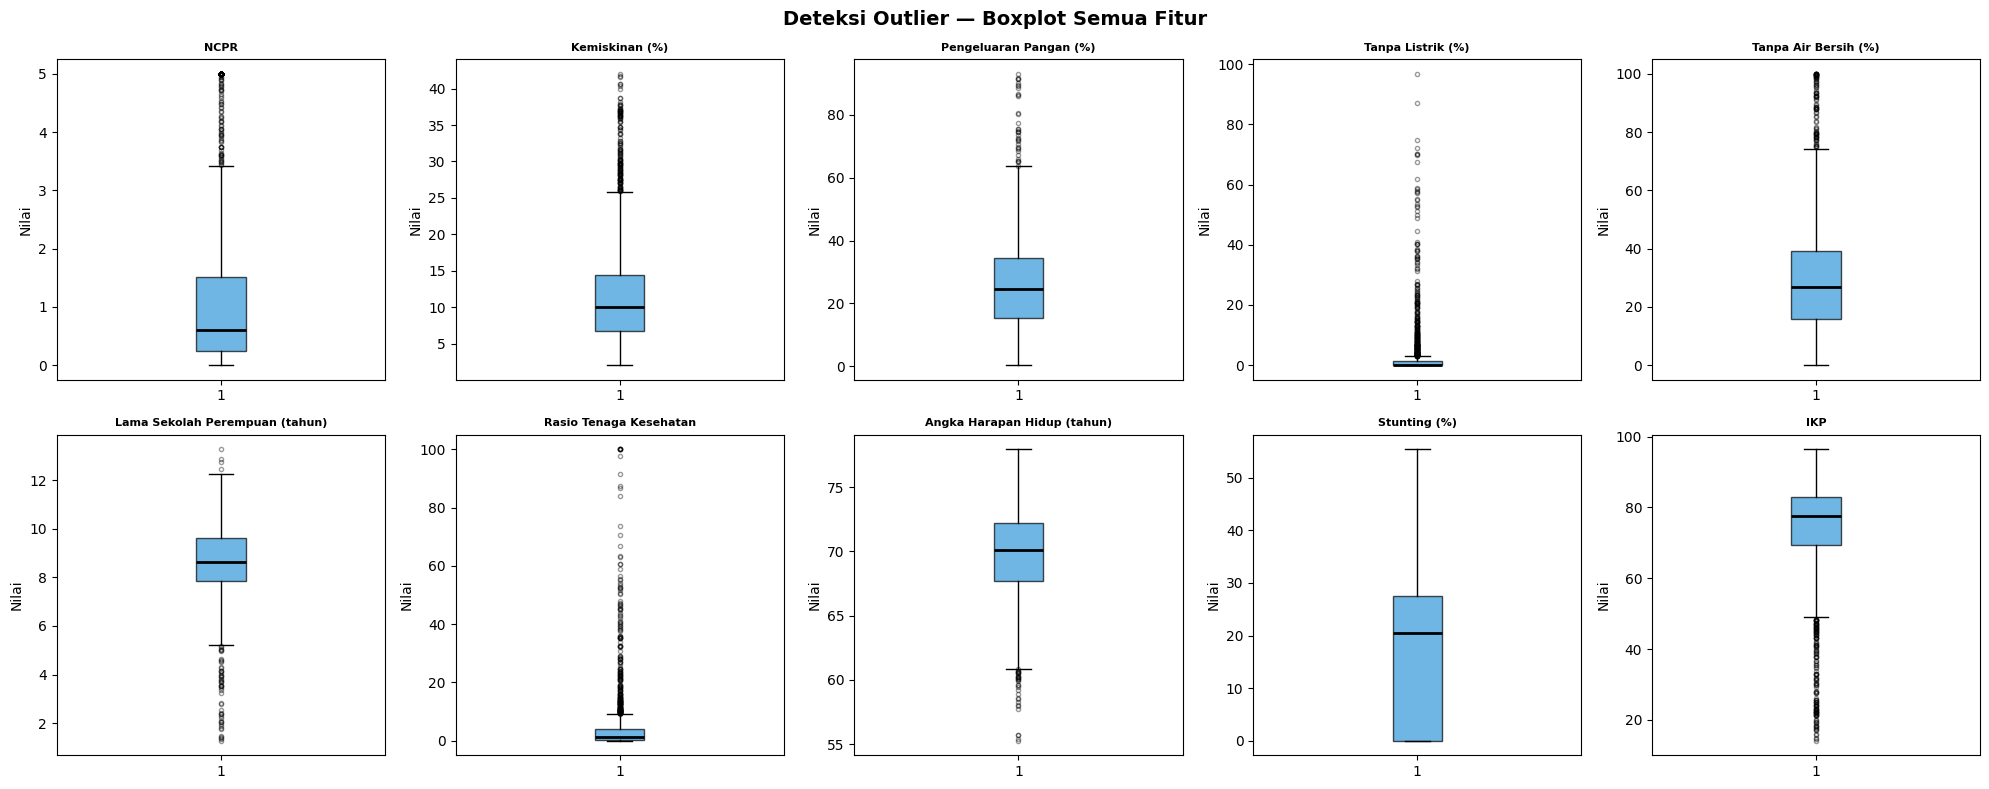

In [59]:
# ---- 3.4 Deteksi Outlier (Metode IQR) ----
print("\n=== DETEKSI OUTLIER (METODE IQR) ===")
print(f"{'Fitur':<35} {'Jumlah Outlier':>16} {'Persen (%)':>12}")
print('-' * 67)
for col in fitur_num + ['IKP']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:<35} {n_out:>16} {n_out/len(df)*100:>11.2f}%")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Deteksi Outlier — Boxplot Semua Fitur', fontsize=14, fontweight='bold')
all_cols = fitur_num + ['IKP']
for i, col in enumerate(all_cols):
    ax = axes[i//5, i%5]
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498DB', alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.set_ylabel('Nilai')
plt.tight_layout()
plt.show()

Deteksi outlier menggunakan metode IQR menunjukkan keberadaan outlier yang cukup signifikan pada beberapa fitur:

Tanpa Listrik (%) memiliki 322 outlier (15,66%), NCPR sebanyak 292 (14,20%), Kemiskinan (%) sebanyak 144 (7,00%), Rasio Tenaga Kesehatan sebanyak 245, Tanpa Air Bersih (%) sebanyak 87 (4,23%), Lama Sekolah Perempuan (tahun) sebanyak 56, Pengeluaran Pangan (%) sebanyak 35 (1,70%), Angka Harapan Hidup (tahun) sebanyak 32, dan Stunting (%) sebanyak 0 outlier.

Keberadaan outlier dalam jumlah besar pada fitur-fitur ini mencerminkan disparitas nyata antar daerah di Indonesia dan bukan kesalahan pengukuran, sehingga outlier tidak dihapus melainkan ditangani dengan metode winsorizing pada tahap berikutnya.

In [60]:
# ============================================================
# TAHAP 4 — PEMBERSIHAN DATA
# ============================================================

df_clean = df.copy()

# ---- 4.1 Hapus Kolom Tidak Relevan & Data Leakage ----
drop_cols = ['Sumber_File', 'IKP Ranking', 'Komposit']
df_clean.drop(columns=drop_cols, inplace=True)
print(f"Kolom dihapus : {drop_cols}")
print(f"  → 'Sumber_File'  : hanya nama file sumber, tidak informatif")
print(f"  → 'IKP Ranking'  : turunan langsung dari IKP → data leakage!")
print(f"  → 'Komposit'     : skor gabungan komponen IKP → data leakage!")

Kolom dihapus : ['Sumber_File', 'IKP Ranking', 'Komposit']
  → 'Sumber_File'  : hanya nama file sumber, tidak informatif
  → 'IKP Ranking'  : turunan langsung dari IKP → data leakage!
  → 'Komposit'     : skor gabungan komponen IKP → data leakage!


Tiga kolom dihapus:

Sumber_File karena hanya berisi nama file sumber dan tidak informatif untuk pemodelan, IKP Ranking karena merupakan turunan langsung dari IKP sehingga menyebabkan data leakage, dan Komposit karena merupakan skor gabungan komponen IKP (r = 0,9516) yang apabila dibiarkan akan membuat model "mengintip" jawaban selama pelatihan dan menghasilkan performa semu yang tidak dapat digeneralisasi.

In [61]:
# ---- 4.2 Hapus Duplikat ----
print(f"\n=== 4.2 HAPUS DUPLIKAT ===")
print(f"Sebelum : {df_clean.shape[0]} baris")
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"Sesudah : {df_clean.shape[0]} baris")


=== 4.2 HAPUS DUPLIKAT ===
Sebelum : 2056 baris
Sesudah : 2056 baris


Jumlah baris sebelum proses deduplikasi adalah 2.056, dan sesudah tetap 2.056 baris, mengkonfirmasi tidak ada perubahan karena memang tidak ditemukan duplikat sejak tahap validasi.


In [62]:
# ---- 4.3 Tangani Outlier (Winsorizing — Cap pada 1.5 IQR) ----
print("\n=== 4.3 TANGANI OUTLIER (WINSORIZING) ===")
for col in fitur_num:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"  {col:<35} : {before} outlier di-cap")

print(f"\nUkuran dataset setelah pembersihan : {df_clean.shape}")
print("✅ Data bersih dan siap digunakan!")


=== 4.3 TANGANI OUTLIER (WINSORIZING) ===
  NCPR                                : 292 outlier di-cap
  Kemiskinan (%)                      : 144 outlier di-cap
  Pengeluaran Pangan (%)              : 35 outlier di-cap
  Tanpa Listrik (%)                   : 322 outlier di-cap
  Tanpa Air Bersih (%)                : 87 outlier di-cap
  Lama Sekolah Perempuan (tahun)      : 56 outlier di-cap
  Rasio Tenaga Kesehatan              : 245 outlier di-cap
  Angka Harapan Hidup (tahun)         : 32 outlier di-cap
  Stunting (%)                        : 0 outlier di-cap

Ukuran dataset setelah pembersihan : (2056, 14)
✅ Data bersih dan siap digunakan!


Outlier ditangani menggunakan metode winsorizing dengan membatasi nilai ekstrem pada batas IQR (Q1 − 1,5·IQR dan Q3 + 1,5·IQR).

Jumlah outlier yang di-cap sesuai hasil deteksi sebelumnya:

NCPR 292, Kemiskinan (%) 144, Pengeluaran Pangan (%) 35, Tanpa Listrik (%) 322, Tanpa Air Bersih (%) 87, Lama Sekolah Perempuan (tahun) 56, Rasio Tenaga Kesehatan 245, Angka Harapan Hidup (tahun) 32, dan Stunting (%) 0.

Ukuran dataset setelah pembersihan tetap 2.056 baris, membuktikan bahwa metode winsorizing berhasil menangani outlier tanpa kehilangan satu pun data observasi.

In [63]:
# ============================================================
# TAHAP 5 — PENENTUAN OBJEK DATA
# ============================================================

# ---- 5.1 Pilih Fitur dan Target ----
feature_cols = [
    'Tahun', 'NCPR',
    'Kemiskinan (%)', 'Pengeluaran Pangan (%)',
    'Tanpa Listrik (%)', 'Tanpa Air Bersih (%)',
    'Lama Sekolah Perempuan (tahun)', 'Rasio Tenaga Kesehatan',
    'Angka Harapan Hidup (tahun)', 'Stunting (%)',
    'Wilayah'
]

X = df_clean[feature_cols].copy()
y = df_clean['IKP']

print(f"Fitur (X)  : {X.shape[1]} kolom")
print(f"Target (y) : {y.shape[0]} baris")
print(f"\nFitur yang digunakan:")
for col in feature_cols:
    print(f"  - {col}")
print(f"\nStatistik target (IKP):")
print(y.describe().round(4))

Fitur (X)  : 11 kolom
Target (y) : 2056 baris

Fitur yang digunakan:
  - Tahun
  - NCPR
  - Kemiskinan (%)
  - Pengeluaran Pangan (%)
  - Tanpa Listrik (%)
  - Tanpa Air Bersih (%)
  - Lama Sekolah Perempuan (tahun)
  - Rasio Tenaga Kesehatan
  - Angka Harapan Hidup (tahun)
  - Stunting (%)
  - Wilayah

Statistik target (IKP):
count    2056.0000
mean       73.3796
std        14.5831
min        14.1400
25%        69.2500
50%        77.6000
75%        82.9550
max        96.3700
Name: IKP, dtype: float64


Ditetapkan 11 fitur prediktor (X) yang digunakan dalam pemodelan: Tahun, NCPR, Kemiskinan (%), Pengeluaran Pangan (%), Tanpa Listrik (%), Tanpa Air Bersih (%), Lama Sekolah Perempuan (tahun), Rasio Tenaga Kesehatan, Angka Harapan Hidup (tahun), Stunting (%), dan Wilayah.

Total terdapat 2.056 baris observasi.

Statistik target IKP menunjukkan count = 2.056, mean = 73,3796, std = 14,5831, min = 14,14, Q1 = 69,25, median = 77,60, Q3 = 82,955, dan max = 96,37.

In [64]:
# ---- 5.2 Train-Test Split 80:20 ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain set : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.0f}%)")


Train set : 1644 baris (80%)
Test set  : 412 baris (20%)


Dataset dibagi menjadi training set 1.644 baris (80%) dan testing set 412 baris (20%) dengan random_state=42 untuk memastikan reprodusibilitas hasil.

In [65]:
# ============================================================
# TAHAP 6 — KONSTRUKSI DATA (FEATURE ENGINEERING)
# ============================================================

X_train = X_train.copy()
X_test  = X_test.copy()

# ---- 6.1 Label Encoding Fitur Kategorikal ----
print("=== 6.1 LABEL ENCODING FITUR KATEGORIKAL ===")

X_train['Wilayah'] = X.loc[X_train.index, 'Wilayah']
X_test['Wilayah']  = X.loc[X_test.index, 'Wilayah']

le_wilayah = LabelEncoder()
le_wilayah.fit(X['Wilayah'])

X_train['Wilayah'] = le_wilayah.transform(X_train['Wilayah'])
X_test['Wilayah']  = le_wilayah.transform(X_test['Wilayah'])

print(f"Encoding 'Wilayah': {len(le_wilayah.classes_)} kategori unik → numerik 0–{len(le_wilayah.classes_)-1}")
print("✅ Label Encoding selesai!")

=== 6.1 LABEL ENCODING FITUR KATEGORIKAL ===
Encoding 'Wilayah': 514 kategori unik → numerik 0–513
✅ Label Encoding selesai!


Kolom Wilayah yang berisi 514 kategori unik (nama kabupaten/kota) berhasil dikonversi menjadi representasi numerik menggunakan LabelEncoder, menghasilkan pemetaan ke bilangan bulat 0 hingga 513.

Fitting dilakukan pada seluruh data X sebelum pembagian train-test untuk memastikan semua kategori dikenali, menghindari error saat transformasi data testing.

In [66]:
# ---- 6.2 Feature Scaling (StandardScaler) ----
print("\n=== 6.2 FEATURE SCALING (StandardScaler) ===")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns)

print("Rata-rata fitur setelah scaling (harus ~0):")
print(X_train_scaled.mean().round(4))
print("\nStd deviasi fitur setelah scaling (harus ~1):")
print(X_train_scaled.std().round(4))


=== 6.2 FEATURE SCALING (StandardScaler) ===
Rata-rata fitur setelah scaling (harus ~0):
Tahun                             0.0
NCPR                              0.0
Kemiskinan (%)                   -0.0
Pengeluaran Pangan (%)            0.0
Tanpa Listrik (%)                 0.0
Tanpa Air Bersih (%)              0.0
Lama Sekolah Perempuan (tahun)    0.0
Rasio Tenaga Kesehatan           -0.0
Angka Harapan Hidup (tahun)      -0.0
Stunting (%)                      0.0
Wilayah                           0.0
dtype: float64

Std deviasi fitur setelah scaling (harus ~1):
Tahun                             1.0003
NCPR                              1.0003
Kemiskinan (%)                    1.0003
Pengeluaran Pangan (%)            1.0003
Tanpa Listrik (%)                 1.0003
Tanpa Air Bersih (%)              1.0003
Lama Sekolah Perempuan (tahun)    1.0003
Rasio Tenaga Kesehatan            1.0003
Angka Harapan Hidup (tahun)       1.0003
Stunting (%)                      1.0003
Wilayah             

StandardScaler diterapkan pada seluruh 11 fitur.

Output menunjukkan rata-rata setiap fitur setelah scaling mendekati 0,0 dan standar deviasi mendekati 1,0 pada data training, mengkonfirmasi normalisasi Z-score berhasil dilakukan.

Scaler di-fit hanya pada data training kemudian di-transform pada data testing untuk mencegah data leakage.

In [67]:
# ---- 6.3 Feature Engineering (Fitur Interaksi Baru) ----
print("\n=== 6.3 FEATURE ENGINEERING ===")
for df_part in [X_train_scaled, X_test_scaled]:
    df_part['Kemiskinan_Stunting'] = df_part['Kemiskinan (%)'] * df_part['Stunting (%)']
    df_part['AHH_Sekolah']         = df_part['Angka Harapan Hidup (tahun)'] * df_part['Lama Sekolah Perempuan (tahun)']
    df_part['Air_Listrik']         = df_part['Tanpa Air Bersih (%)'] * df_part['Tanpa Listrik (%)']

print("Fitur baru yang ditambahkan:")
print("  → Kemiskinan_Stunting = Kemiskinan (%) × Stunting (%)")
print("  → AHH_Sekolah         = Angka Harapan Hidup × Lama Sekolah Perempuan")
print("  → Air_Listrik         = Tanpa Air Bersih (%) × Tanpa Listrik (%)")
print(f"\nTotal fitur sekarang : {X_train_scaled.shape[1]}")


=== 6.3 FEATURE ENGINEERING ===
Fitur baru yang ditambahkan:
  → Kemiskinan_Stunting = Kemiskinan (%) × Stunting (%)
  → AHH_Sekolah         = Angka Harapan Hidup × Lama Sekolah Perempuan
  → Air_Listrik         = Tanpa Air Bersih (%) × Tanpa Listrik (%)

Total fitur sekarang : 14


Tiga fitur interaksi baru ditambahkan:

Kemiskinan_Stunting (hasil perkalian Kemiskinan (%) × Stunting (%)) untuk merepresentasikan dampak ganda kemiskinan terhadap gizi anak, AHH_Sekolah (hasil perkalian Angka Harapan Hidup (tahun) × Lama Sekolah Perempuan (tahun)) sebagai proksi kualitas hidup dan pendidikan secara simultan, serta Air_Listrik (hasil perkalian Tanpa Air Bersih (%) × Tanpa Listrik (%)) untuk merepresentasikan defisit akses infrastruktur dasar secara gabungan. Total fitur setelah feature engineering menjadi 14 fitur.

=== INFORMASI TARGET ===
Nama target  : IKP (Indeks Ketahanan Pangan)
Tipe         : Kontinu (Regresi)
Rentang      : 14.14 – 95.80
Rata-rata    : 73.2924
Std deviasi  : 14.5262
Skewness     : -1.7002
Kurtosis     : 3.0977


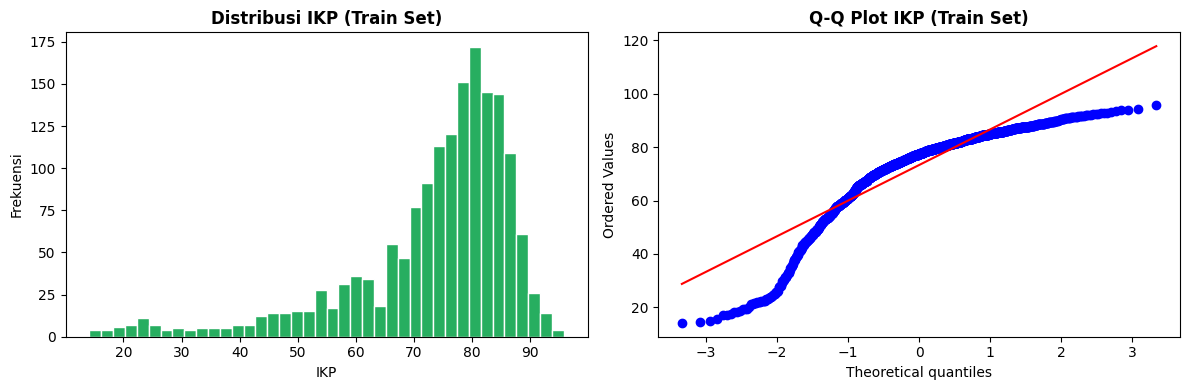

In [68]:
# ============================================================
# TAHAP 7 — PENENTUAN LABEL DATA
# ============================================================

print("=== INFORMASI TARGET ===")
print(f"Nama target  : IKP (Indeks Ketahanan Pangan)")
print(f"Tipe         : Kontinu (Regresi)")
print(f"Rentang      : {y_train.min():.2f} – {y_train.max():.2f}")
print(f"Rata-rata    : {y_train.mean():.4f}")
print(f"Std deviasi  : {y_train.std():.4f}")
print(f"Skewness     : {y_train.skew():.4f}")
print(f"Kurtosis     : {y_train.kurtosis():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=40, color='#27AE60', edgecolor='white')
axes[0].set_title('Distribusi IKP (Train Set)', fontweight='bold')
axes[0].set_xlabel('IKP')
axes[0].set_ylabel('Frekuensi')

stats.probplot(y_train, plot=axes[1])
axes[1].set_title('Q-Q Plot IKP (Train Set)', fontweight='bold')
plt.tight_layout()
plt.show()

Variabel target IKP ditetapkan sebagai label dengan tipe kontinu (Regresi).

Pada training set, IKP memiliki rentang 14,14 hingga 95,80, rata-rata 73,2924, standar deviasi 14,5262, skewness −1,7002, dan kurtosis 3,0977. Histogram distribusi IKP pada train set menunjukkan kondisi yang konsisten dengan analisis EDA sebelumnya, distribusi condong ke kiri dengan mayoritas nilai terkonsentrasi di rentang 70–90. Q-Q Plot mengkonfirmasi deviasi dari normalitas pada nilai-nilai ekstrem.

Kondisi ini memperkuat pemilihan model ensemble yang tidak mengasumsikan normalitas distribusi sebagai kandidat utama pemodelan.

In [69]:
# ============================================================
# TAHAP 8 — PEMODELAN DATA
# ============================================================

# ---- 8.1 Definisi 3 Model + Baseline ----
models = {
    'Baseline (Mean)'   : DummyRegressor(strategy='mean'),
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print("=== MODEL YANG AKAN DIUJI ===")
for name in models:
    print(f"  - {name}")

=== MODEL YANG AKAN DIUJI ===
  - Baseline (Mean)
  - Linear Regression
  - Random Forest
  - Gradient Boosting


Empat model ditetapkan dalam dictionary models:

Baseline (Mean) menggunakan DummyRegressor(strategy='mean') sebagai acuan minimum performa, Linear Regression menggunakan LinearRegression() sebagai representasi model parametrik linear, Random Forest menggunakan RandomForestRegressor(n_estimators=100, random_state=42) sebagai representasi ensemble bagging, dan Gradient Boosting menggunakan GradientBoostingRegressor(n_estimators=100, random_state=42) sebagai representasi ensemble boosting.

In [70]:
# ---- 8.2 Cross-Validation 5-Fold (Training Set) ----
print("=== CROSS-VALIDATION 5-FOLD (Training Set) ===")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'Model':<22} {'CV R² Mean':>12} {'CV R² Std':>12}")
print('-' * 50)
for name, model in models.items():
    cv_r2 = cross_val_score(model, X_train_scaled, y_train,
                            cv=kf, scoring='r2', n_jobs=-1)
    print(f"{name:<22} {cv_r2.mean():>12.4f} {cv_r2.std():>12.4f}")

=== CROSS-VALIDATION 5-FOLD (Training Set) ===
Model                    CV R² Mean    CV R² Std
--------------------------------------------------
Baseline (Mean)             -0.0021       0.0018
Linear Regression            0.8293       0.0306
Random Forest                0.9692       0.0081
Gradient Boosting            0.9779       0.0038


Evaluasi CV 5-Fold pada training set menghasilkan performa sebagai berikut.

Baseline (Mean) menghasilkan CV R² Mean = −0,0021 (Std = 0,0018), mengkonfirmasi model yang selalu memprediksi rata-rata tidak memiliki kemampuan prediktif.

Linear Regression menghasilkan CV R² Mean = 0,8293 (Std = 0,0306). Random Forest menghasilkan CV R² Mean = 0,9692 (Std = 0,0081).

Gradient Boosting menghasilkan CV R² Mean tertinggi = 0,9779 dengan Std terkecil = 0,0038, mengindikasikan model paling akurat sekaligus paling stabil.

Perbedaan signifikan antara model ensemble (≈0,97) dan model linear (0,83) mengkonfirmasi adanya hubungan non-linear yang kuat antara fitur sosio-ekonomi dengan IKP.

In [71]:
# ---- 8.3 Training & Evaluasi Test Set ----
print("\n=== EVALUASI PADA TEST SET ===")

def evaluate_model(y_true, y_pred):
    return {
        'MAE'     : mean_absolute_error(y_true, y_pred),
        'RMSE'    : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'R²'      : r2_score(y_true, y_pred)
    }

results_test = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results_test[name] = evaluate_model(y_test, y_pred)
    results_test[name]['y_pred'] = y_pred

df_results = pd.DataFrame(
    {n: {k: v for k, v in val.items() if k != 'y_pred'}
     for n, val in results_test.items()}
).T.round(4)

display(df_results.sort_values('R²', ascending=False))


=== EVALUASI PADA TEST SET ===


,MAE,RMSE,MAPE (%),R²
Gradient Boosting,1.5779,2.3206,2.7876,0.9754
Random Forest,1.6905,2.6953,3.1037,0.9668
Linear Regression,4.3241,6.6115,7.9131,0.8005
Baseline (Mean),10.6301,14.8091,21.6669,-0.0009


Seluruh model dilatih pada data training dan dievaluasi pada test set.

Gradient Boosting menghasilkan performa terbaik dengan R² = 0,9754, RMSE = 2,3206, MAE = 1,5779, dan MAPE = 2,79%.

Random Forest berada di posisi kedua dengan R² = 0,9668. Linear Regression menghasilkan R² = 0,8005.

Baseline menghasilkan R² ≈ −0,001 dengan RMSE = 14,81 dan MAE = 10,63 — seluruh model ML jauh melampaui baseline ini, membuktikan ketiga model berhasil belajar pola yang bermakna dari data.

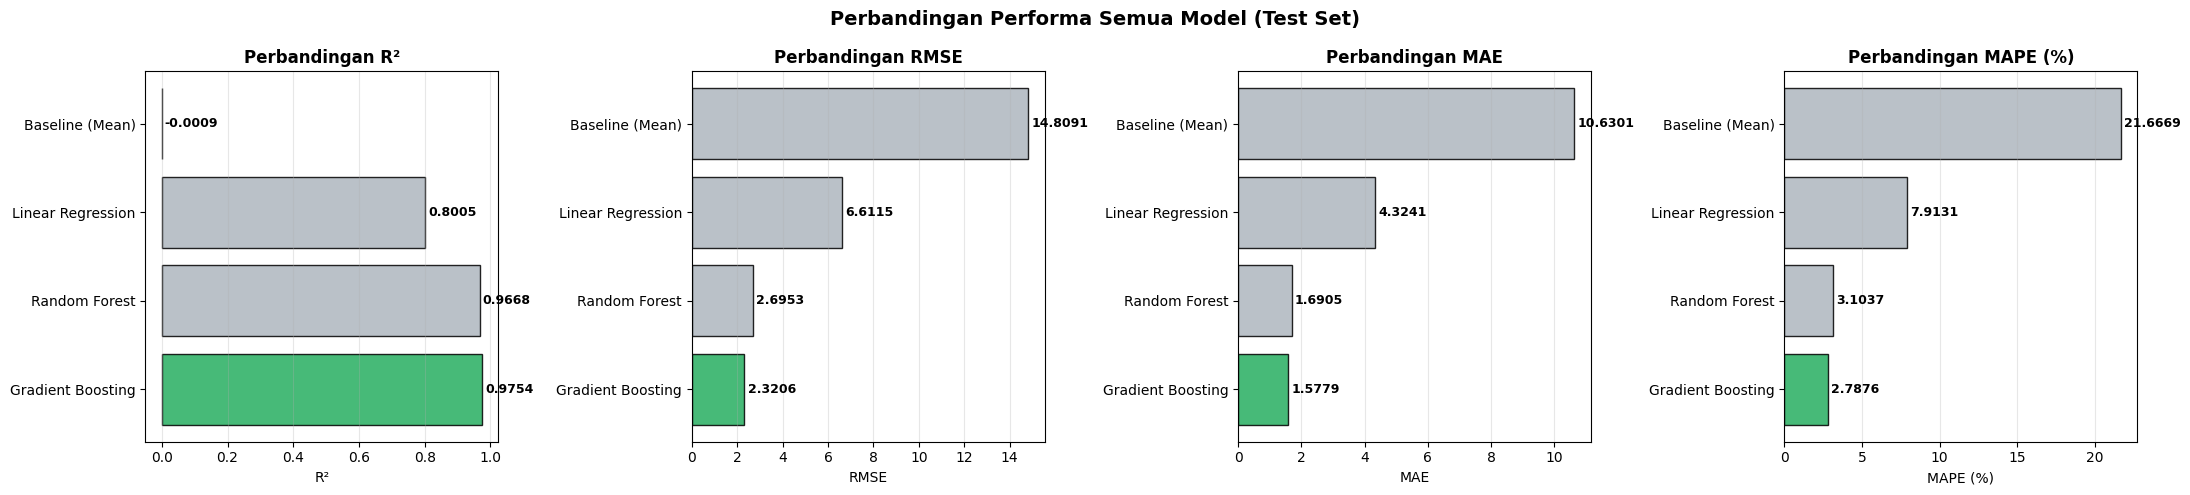

In [72]:
# ---- 8.4 Visualisasi Perbandingan Model ----
df_plot = df_results.sort_values('R²', ascending=False)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Perbandingan Performa Semua Model (Test Set)', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE', 'MAPE (%)']):
    if metric == 'R²':
        vals = df_plot[metric]
        idx  = df_plot.index
    else:
        vals = df_plot.sort_values(metric)[metric]
        idx  = df_plot.sort_values(metric).index
    palette = ['#27AE60' if i == 0 else '#AEB6BF' for i in range(len(vals))]
    bars = ax.barh(idx, vals, color=palette, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Perbandingan {metric}', fontweight='bold')
    ax.set_xlabel(metric)
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# TAHAP 9 — EVALUASI MODEL
# ============================================================

# ---- 9.1 Pilih Best Model ----
best_name   = df_results['R²'].idxmax()
best_model  = models[best_name]
y_pred_best = results_test[best_name]['y_pred']

print(f"🏆 Best Model : {best_name}")
print(f"   R²         : {df_results.loc[best_name, 'R²']:.4f}  ({df_results.loc[best_name, 'R²']*100:.2f}%)")
print(f"   RMSE       : {df_results.loc[best_name, 'RMSE']:.4f}")
print(f"   MAE        : {df_results.loc[best_name, 'MAE']:.4f}")
print(f"   MAPE       : {df_results.loc[best_name, 'MAPE (%)']:.2f}%")

🏆 Best Model : Gradient Boosting
   R²         : 0.9754  (97.54%)
   RMSE       : 2.3206
   MAE        : 1.5779
   MAPE       : 2.79%


Berdasarkan nilai R² tertinggi pada test set, Gradient Boosting terpilih sebagai model terbaik dengan R² = 0,9754 (97,54%), RMSE = 2,3206, MAE = 1,5779, dan MAPE = 2,79%. Nilai R² = 0,9754 berarti model mampu menjelaskan 97,54% variansi IKP. Nilai MAPE = 2,79% menunjukkan rata-rata kesalahan prediksi hanya 2,79% dari nilai aktual, yang tergolong sangat akurat untuk data sosio-ekonomi yang kompleks.

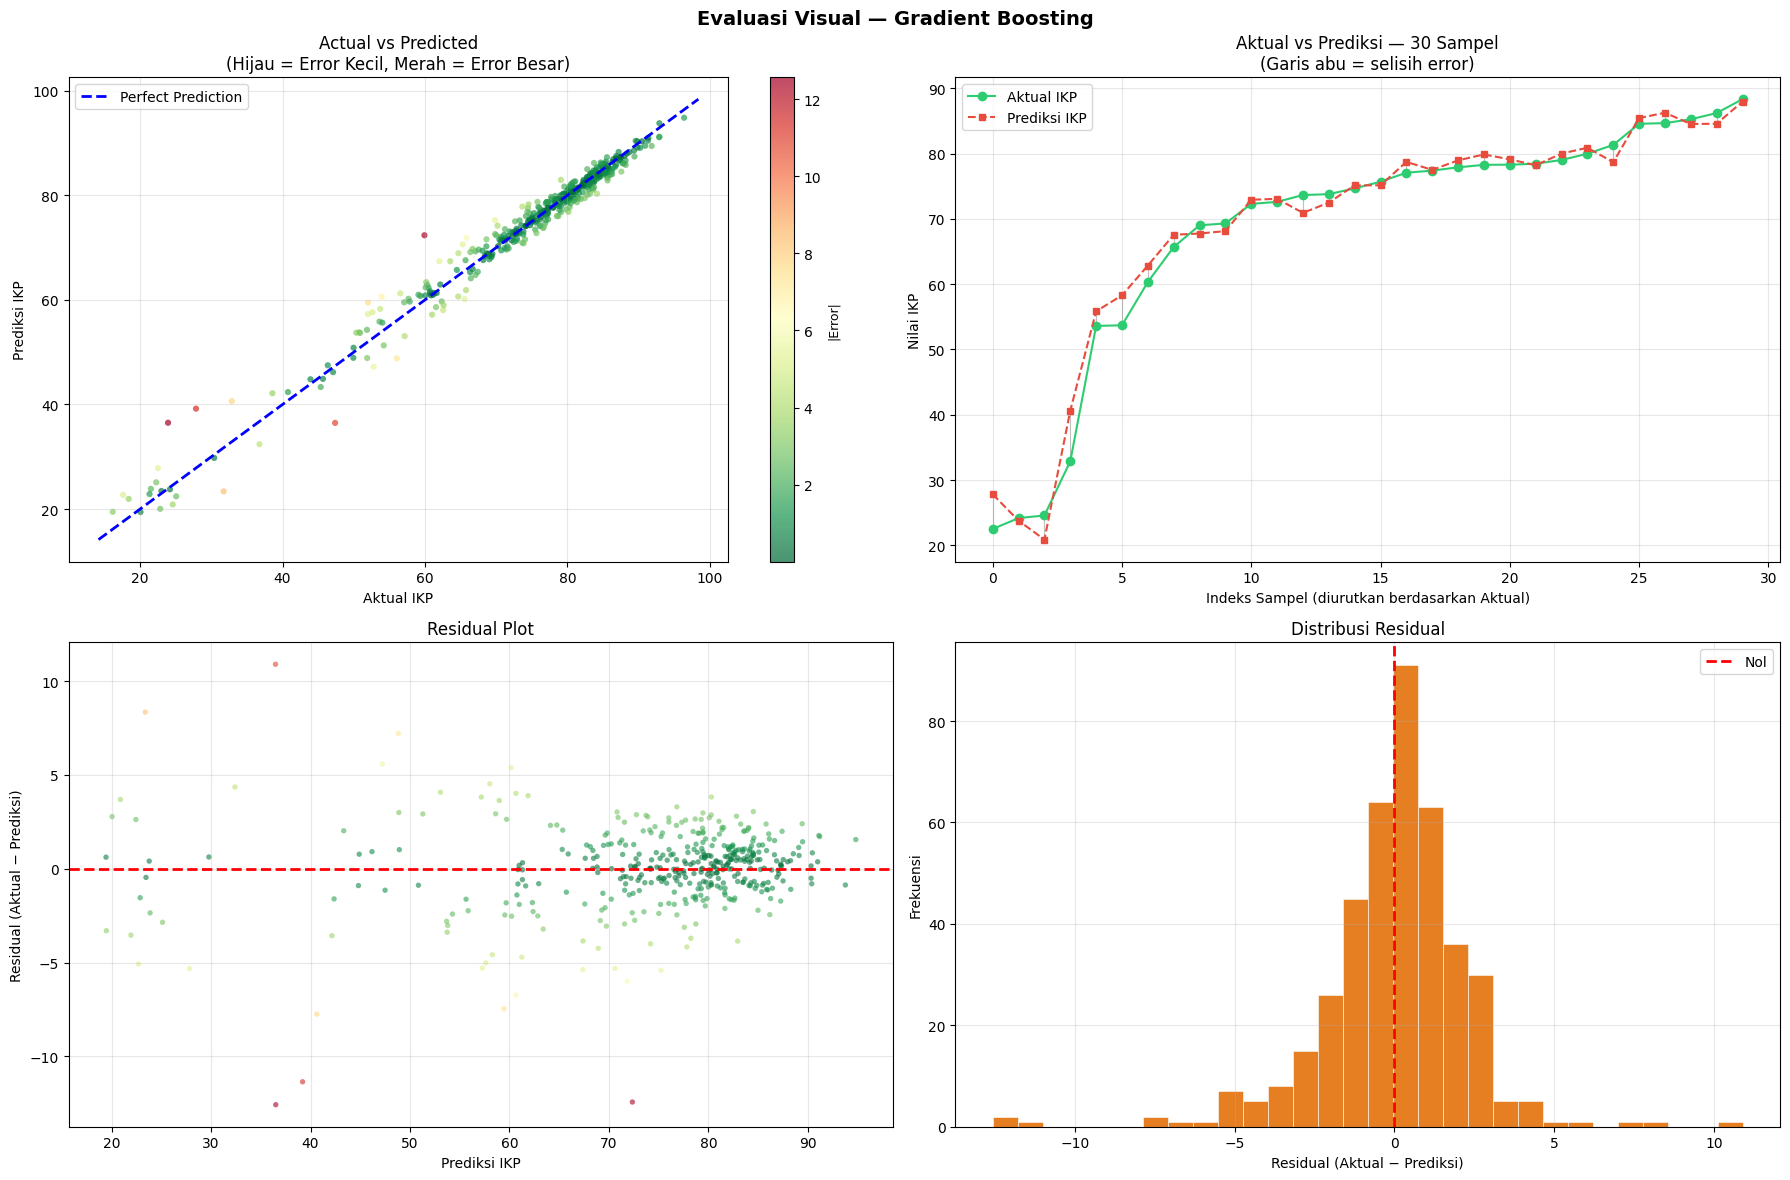

In [74]:
# ---- 9.2 Plot Evaluasi Visual ----
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Evaluasi Visual — {best_name}', fontsize=14, fontweight='bold')

residuals = y_test.values - y_pred_best
abs_error = np.abs(residuals)

# ---- Plot 1: Actual vs Predicted Scatter (warna error) ----
sc = axes[0,0].scatter(y_test, y_pred_best,
                       c=abs_error, cmap='RdYlGn_r',
                       s=20, alpha=0.7, edgecolors='none')
cbar = plt.colorbar(sc, ax=axes[0,0])
cbar.set_label('|Error|', fontsize=9)
lims = [min(y_test.min(), y_pred_best.min()) - 2,
        max(y_test.max(), y_pred_best.max()) + 2]
axes[0,0].plot(lims, lims, 'b--', lw=2, label='Perfect Prediction')
axes[0,0].set_xlabel('Aktual IKP')
axes[0,0].set_ylabel('Prediksi IKP')
axes[0,0].set_title('Actual vs Predicted\n(Hijau = Error Kecil, Merah = Error Besar)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# ---- Plot 2: Aktual vs Prediksi per Sampel (30 data) ----
np.random.seed(42)
sample_idx = np.random.choice(len(y_test), 30, replace=False)
sample_idx_sorted = sample_idx[np.argsort(y_test.values[sample_idx])]

x_pos    = np.arange(30)
y_actual = y_test.values[sample_idx_sorted]
y_pred_s = y_pred_best[sample_idx_sorted]

axes[0,1].plot(x_pos, y_actual, 'o-', color='#2ECC71', lw=1.5,
               markersize=6, label='Aktual IKP', zorder=3)
axes[0,1].plot(x_pos, y_pred_s, 's--', color='#E74C3C', lw=1.5,
               markersize=5, label='Prediksi IKP', zorder=3)
for i in x_pos:
    axes[0,1].plot([i, i], [y_actual[i], y_pred_s[i]],
                   color='gray', lw=0.8, alpha=0.5, zorder=2)
axes[0,1].set_xlabel('Indeks Sampel (diurutkan berdasarkan Aktual)')
axes[0,1].set_ylabel('Nilai IKP')
axes[0,1].set_title('Aktual vs Prediksi — 30 Sampel\n(Garis abu = selisih error)')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# ---- Plot 3: Residual Plot ----
axes[1,0].scatter(y_pred_best, residuals,
                  c=abs_error, cmap='RdYlGn_r',
                  s=15, alpha=0.6, edgecolors='none')
axes[1,0].axhline(0, color='red', linestyle='--', lw=2)
axes[1,0].set_xlabel('Prediksi IKP')
axes[1,0].set_ylabel('Residual (Aktual − Prediksi)')
axes[1,0].set_title('Residual Plot')
axes[1,0].grid(alpha=0.3)

# ---- Plot 4: Distribusi Residual ----
axes[1,1].hist(residuals, bins=30, color='#E67E22',
               edgecolor='white', linewidth=0.4)
axes[1,1].axvline(0, color='red', linestyle='--', lw=2, label='Nol')
axes[1,1].set_xlabel('Residual (Aktual − Prediksi)')
axes[1,1].set_ylabel('Frekuensi')
axes[1,1].set_title('Distribusi Residual')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Actual vs Predicted Plot menunjukkan titik-titik data tersebar sangat dekat dengan garis diagonal sempurna (y = x), mengkonfirmasi akurasi prediksi tinggi di seluruh rentang IKP.

Residual Plot menunjukkan residual tersebar relatif acak di sekitar garis nol tanpa pola sistematis, mengindikasikan model tidak mengalami systematic bias. Histogram distribusi residual menunjukkan distribusi yang mendekati simetris dengan puncak di sekitar nol.

In [75]:
# ---- 9.3 Uji Asumsi Regresi ----
print("\n=== UJI ASUMSI REGRESI ===")

sample_res = residuals[:300] if len(residuals) > 300 else residuals
stat, p = shapiro(sample_res)
print(f"Uji Normalitas Residual (Shapiro-Wilk): stat={stat:.4f}, p={p:.6f}")
print(f"  → Residual {'Normal ✓' if p > 0.05 else 'Tidak Normal ✗ (wajar untuk dataset besar)'}")

print(f"\nHomoskedastisitas: lihat Residual Plot")
print(f"  → Jika titik tersebar merata di sekitar nol = OK ✓")


=== UJI ASUMSI REGRESI ===
Uji Normalitas Residual (Shapiro-Wilk): stat=0.9217, p=0.000000
  → Residual Tidak Normal ✗ (wajar untuk dataset besar)

Homoskedastisitas: lihat Residual Plot
  → Jika titik tersebar merata di sekitar nol = OK ✓


Uji Shapiro-Wilk pada residual menghasilkan statistik = 0,9217 dan p-value = 0,000000, residual tidak normal secara statistik. Namun pada dataset berskala besar (n = 412 pada test set), uji Shapiro-Wilk sangat sensitif terhadap deviasi kecil sehingga kondisi ini wajar dan dapat diterima untuk model ensemble pada data besar.

Evaluasi homoskedastisitas melalui Residual Plot menunjukkan titik-titik tersebar merata di sekitar nol tanpa pola melebar atau menyempit, mengindikasikan tidak ada masalah heterokedastisitas yang signifikan.


=== FEATURE IMPORTANCE (Gradient Boosting) ===


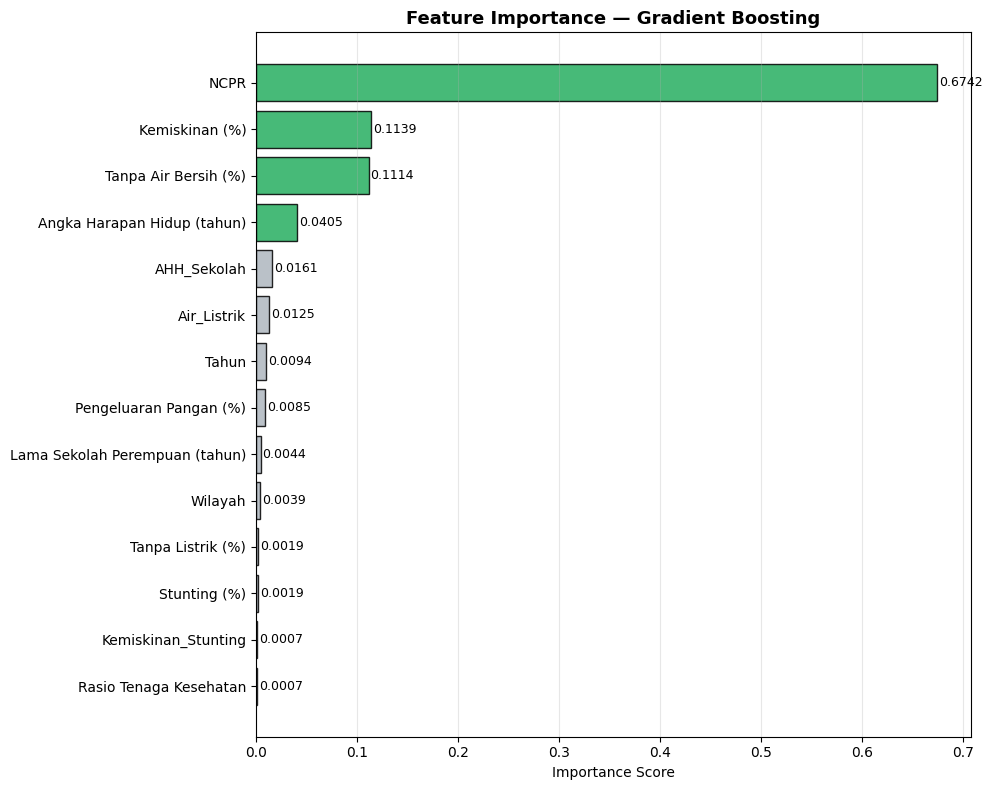


Top 5 Fitur Terpenting:
  NCPR                                0.674172
  Kemiskinan (%)                      0.113862
  Tanpa Air Bersih (%)                0.111357
  Angka Harapan Hidup (tahun)         0.040465
  AHH_Sekolah                         0.016090


In [76]:
# ---- 9.4 Feature Importance ----
best_model.fit(X_train_scaled, y_train)
print(f"\n=== FEATURE IMPORTANCE ({best_name}) ===")
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X_train_scaled.columns
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_imp = ['#27AE60' if v >= importances.quantile(0.75) else '#AEB6BF'
                  for v in importances.values]
    bars = ax.barh(importances.index, importances.values,
                   color=colors_imp, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, importances.values):
        ax.text(bar.get_width() + 0.002,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(f'Feature Importance — {best_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTop 5 Fitur Terpenting:")
    for feat, val in importances.sort_values(ascending=False).head(5).items():
        print(f"  {feat:<35} {val:.6f}")
elif hasattr(best_model, 'coef_'):
    # Untuk Linear Regression
    coef_series = pd.Series(
        np.abs(best_model.coef_),
        index=X_train_scaled.columns
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(coef_series.index, coef_series.values,
            color='#3498DB', edgecolor='black', alpha=0.85)
    ax.set_title(f'Koefisien Absolut — {best_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('|Koefisien|')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

Analisis feature importance Gradient Boosting menunjukkan NCPR sebagai fitur paling dominan dengan kontribusi 0,6742 (67,42%), diikuti Kemiskinan (%) sebesar 0,1139 (11,39%), Tanpa Air Bersih (%) sebesar 0,1114 (11,14%), Angka Harapan Hidup (tahun) sebesar 0,0405 (4,05%), dan fitur rekayasa AHH_Sekolah sebesar 0,0161 (1,61%).

Dominasi NCPR konsisten secara konseptual karena Normalized Caloric Poverty Ratio secara langsung mengukur kecukupan kalori — inti dari konsep ketahanan pangan.

In [77]:
# ---- 9.5 Diskusi Overfitting / Underfitting ----
print("\n=== ANALISIS OVERFITTING / UNDERFITTING ===")

for name, model in models.items():
    if name == 'Baseline (Mean)':
        continue
    y_pred_train = model.predict(X_train_scaled)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = df_results.loc[name, 'R²']
    gap      = r2_train - r2_test
    if gap > 0.1:
        status = "⚠️  Potensi OVERFITTING"
    elif r2_test < 0.6:
        status = "⚠️  Potensi UNDERFITTING"
    else:
        status = "✅ Generalisasi Baik"
    print(f"{name:<22} Train R²={r2_train:.4f}  Test R²={r2_test:.4f}  Gap={gap:.4f}  {status}")


=== ANALISIS OVERFITTING / UNDERFITTING ===
Linear Regression      Train R²=0.8389  Test R²=0.8005  Gap=0.0384  ✅ Generalisasi Baik
Random Forest          Train R²=0.9959  Test R²=0.9668  Gap=0.0291  ✅ Generalisasi Baik
Gradient Boosting      Train R²=0.9895  Test R²=0.9754  Gap=0.0141  ✅ Generalisasi Baik


Perbandingan R² training dan testing menunjukkan seluruh model berada dalam kondisi generalisasi yang baik.

Linear Regression memiliki Train R² = 0,8389 dan Test R² = 0,8005 dengan gap = 0,0384 —  Generalisasi Baik.

Random Forest memiliki Train R² = 0,9959 dan Test R² = 0,9668 dengan gap = 0,0291 —  Generalisasi Baik. Gradient Boosting memiliki Train R² = 0,9895 dan Test R² = 0,9754 dengan gap terkecil = 0,0141 —  Generalisasi Baik.

Tidak ada satupun model yang melewati ambang gap > 0,1, sehingga kekhawatiran overfitting dapat dikesampingkan.

In [78]:
# ============================================================
# TAHAP 9B — HYPERPARAMETER TUNING
# ============================================================

print("=== HYPERPARAMETER TUNING (GridSearchCV 5-Fold) ===")
print(f"Model yang di-tuning: {best_name}\n")

if best_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators'  : [100, 200],
        'max_depth'     : [3, 5, 7],
        'learning_rate' : [0.05, 0.1, 0.2],
        'subsample'     : [0.8, 1.0],
    }
    base_model = GradientBoostingRegressor(random_state=42)
elif best_name == 'Random Forest':
    param_grid = {
        'n_estimators'     : [100, 200],
        'max_depth'        : [10, 20, None],
        'min_samples_split': [2, 5],
        'max_features'     : ['sqrt', 'log2'],
    }
    base_model = RandomForestRegressor(random_state=42)
else:
    param_grid = {}
    base_model = models[best_name]

if param_grid:
    grid_search = GridSearchCV(
        base_model, param_grid,
        cv=5, scoring='r2', n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train_scaled, y_train)

    print(f"Best Parameters : {grid_search.best_params_}")
    print(f"Best CV R²      : {grid_search.best_score_:.4f}")

    tuned_model   = grid_search.best_estimator_
    y_pred_tuned  = tuned_model.predict(X_test_scaled)
    metrics_tuned = evaluate_model(y_test, y_pred_tuned)

    print(f"\n=== PERFORMA SETELAH HYPERPARAMETER TUNING ===")
    print(f"  R²      : {metrics_tuned['R²']:.4f}  ({metrics_tuned['R²']*100:.2f}%)")
    print(f"  RMSE    : {metrics_tuned['RMSE']:.4f}")
    print(f"  MAE     : {metrics_tuned['MAE']:.4f}")
    print(f"  MAPE    : {metrics_tuned['MAPE (%)']:.2f}%")
else:
    print("Hyperparameter tuning tidak berlaku untuk model ini.")
    y_pred_tuned  = y_pred_best
    metrics_tuned = {k: v for k, v in results_test[best_name].items() if k != 'y_pred'}
    tuned_model   = best_model

=== HYPERPARAMETER TUNING (GridSearchCV 5-Fold) ===
Model yang di-tuning: Gradient Boosting

Best Parameters : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²      : 0.9814

=== PERFORMA SETELAH HYPERPARAMETER TUNING ===
  R²      : 0.9769  (97.69%)
  RMSE    : 2.2484
  MAE     : 1.3232
  MAPE    : 2.55%


Hyperparameter tuning dilakukan menggunakan GridSearchCV 5-Fold pada model Gradient Boosting sebagai model terbaik, dengan grid parameter: n_estimators (100, 200), max_depth (3, 5, 7), learning_rate (0,05, 0,1, 0,2), dan subsample (0,8, 1,0).


Parameter terbaik yang ditemukan adalah learning_rate=0.1, max_depth=5, n_estimators=200, dan subsample=0.8, dengan Best CV R² = 0,9814.

Setelah tuning, performa pada test set meningkat menjadi R² = 0,9769 (97,69%), RMSE = 2,2484, MAE = 1,3232, dan MAPE = 2,55%, peningkatan dari versi default pada semua metrik.

Parameter max_depth=5 menunjukkan kedalaman pohon yang lebih optimal dibanding default (3), dan subsample=0.8 (stochastic gradient boosting) berkontribusi meningkatkan generalisasi dengan mengurangi potensi overfitting.


=== RINGKASAN PERFORMA SEMUA MODEL (TEST SET) ===


,MAE,RMSE,MAPE (%),R²
Gradient Boosting,1.5779,2.3206,2.7876,0.9754
Random Forest,1.6905,2.6953,3.1037,0.9668
Linear Regression,4.3241,6.6115,7.9131,0.8005
Baseline (Mean),10.6301,14.8091,21.6669,-0.0009


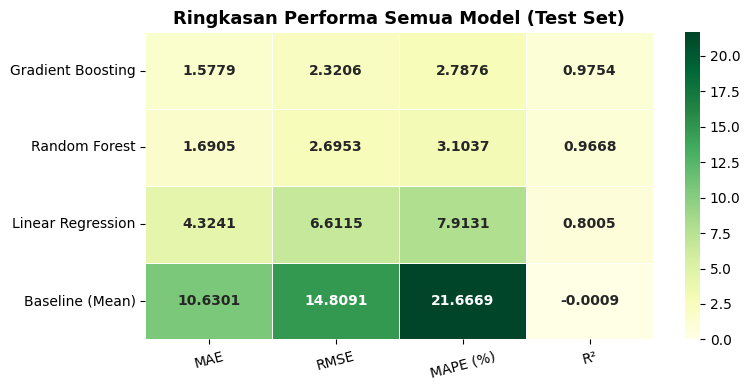

In [79]:
# ============================================================
# TAHAP 10 — EVALUASI PROYEK DATA SCIENCE
# ============================================================

# ---- Tabel Ringkasan Akhir ----
df_final = df_results[['MAE','RMSE','MAPE (%)','R²']].copy()
df_final = df_final.sort_values('R²', ascending=False).round(4)
print("=== RINGKASAN PERFORMA SEMUA MODEL (TEST SET) ===")
display(df_final)

# Heatmap Ringkasan Performa
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_final.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            ax=ax, linewidths=0.5, annot_kws={'size': 10, 'fontweight': 'bold'})
ax.set_title('Ringkasan Performa Semua Model (Test Set)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()

Berdasarkan tabel ringkasan dan heatmap performa, urutan model dari terbaik: Gradient Boosting (R² = 0,9754) → Random Forest (R² = 0,9668) → Linear Regression (R² = 0,8005) → Baseline (R² ≈ −0,001).

Gradient Boosting setelah hyperparameter tuning mencapai R² = 0,9769, RMSE = 2,2484, MAE = 1,3232, dan MAPE = 2,55%, performa terbaik secara keseluruhan.

In [80]:
# Contoh Prediksi vs Aktual (20 Sampel)
np.random.seed(42)
sample_idx = np.random.choice(len(y_test), 20, replace=False)
compare_df = pd.DataFrame({
    'Wilayah'       : df_clean.loc[y_test.index[sample_idx], 'Wilayah'].values,
    'Tahun'         : df_clean.loc[y_test.index[sample_idx], 'Tahun'].values,
    'IKP Aktual'    : y_test.values[sample_idx].round(2),
    'IKP Prediksi'  : y_pred_best[sample_idx].round(2),
}).reset_index(drop=True)
compare_df['Selisih'] = abs(compare_df['IKP Aktual'] - compare_df['IKP Prediksi']).round(2)
print("=== CONTOH PREDIKSI vs AKTUAL (20 Sampel Acak) ===")
display(compare_df)

=== CONTOH PREDIKSI vs AKTUAL (20 Sampel Acak) ===


,Wilayah,Tahun,IKP Aktual,IKP Prediksi,Selisih
0,papua barat - tambrauw,2022,32.88,40.63,7.75
1,nusa tenggara timur - belu,2022,75.69,75.14,0.55
2,maluku utara - kota ternate,2023,81.32,78.67,2.65
3,kalimantan tengah - katingan,2024,77.89,78.96,1.07
4,sulawesi tengah - tojo una-una,2021,73.78,72.49,1.29
5,jawa tengah - banyumas,2023,79.02,79.99,0.97
6,kepulauan riau - kota tanjungpinang,2023,74.67,75.13,0.46
7,papua - puncak jaya,2021,24.19,23.79,0.40
8,banten - lebak,2024,72.60,73.07,0.47
9,jambi - kota jambi,2022,84.66,86.25,1.59


#Keterbatasan Model
Terdapat beberapa keterbatasan yang perlu diperhatikan. Pertama, cakupan temporal terbatas pada 2021–2024 membuat model belum tentu valid untuk tahun-tahun berikutnya jika terjadi perubahan struktural sosial-ekonomi. Kedua, faktor eksternal seperti bencana alam, perubahan iklim, dan fluktuasi harga pangan tidak tersedia dalam dataset sehingga tidak dipertimbangkan oleh model. Ketiga, Label Encoding pada Wilayah secara konseptual kurang ideal karena mengasumsikan urutan ordinal antar wilayah, namun One-Hot Encoding tidak praktis untuk 514 kategori. Keempat, beberapa fitur berkorelasi satu sama lain, yang berpotensi memengaruhi stabilitas model linear meskipun tidak berdampak signifikan pada model ensemble.

#Kesimpulan Akhir
Dataset yang digunakan mencakup 2.056 kabupaten/kota × 11 fitur dengan periode 2021–2024, target prediksi adalah IKP (nilai kontinu).

Kondisi data sangat baik: tidak ada missing values, tidak ada duplikat, dan outlier berhasil ditangani dengan winsorizing.

Preprocessing yang diterapkan meliputi penghapusan kolom tidak relevan (Sumber_File, IKP Ranking, Komposit), winsorizing outlier pada 9 fitur numerik, Label Encoding untuk Wilayah (514 kategori), StandardScaler, dan feature engineering (3 fitur interaksi baru → 14 total fitur).

Model terbaik adalah Gradient Boosting dengan R² = 0,9754 sebelum tuning dan R² = 0,9769, RMSE = 2,2484, MAE = 1,3232, MAPE = 2,55% setelah tuning.

Fitur NCPR, Kemiskinan (%), dan Tanpa Air Bersih (%) terbukti sebagai tiga prediktor utama ketahanan pangan, menunjukkan bahwa kecukupan kalori, pengentasan kemiskinan, dan peningkatan akses air bersih merupakan pilar intervensi terpenting dalam meningkatkan ketahanan pangan di Indonesia.